# Task 3 v2 — Evaluation on Mixed QCD + Emerging Jets Samples

Versione più aderente alle richieste del Task 3 del progetto.

Questa versione migliora il notebook precedente perché:

1. confronta tutti gli anomaly score disponibili su QCD vs EJ;
2. produce ROC/AUC;
3. produce signal efficiency vs QCD mistag rate;
4. confronta con baseline supervisionate;
5. controlla train-vs-test-background;
6. usa `truth_dark_pions` dal file `pp_output_test_signal.h5` per studiare la sensitivity in funzione di:
   - truth-level dark pion mass;
   - truth-level transverse decay length `Lxy`;
   - `Lxy_prod`;
   - numero di dark pions validi;
7. mantiene anche proxy track-level come controllo opzionale;
8. salva tabelle `.csv` pronte da mettere nel report.

Importante: le variabili truth-level sono usate **solo per valutazione**, non come input ai modelli.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)

OUTPUT_DIR = Path("outputs_task3_v2")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

## 1. Configurazione file

In [2]:
# File raw usato solo per leggere truth_dark_pions del signal.
SIGNAL_H5 = Path("pp_output_test_signal.h5")

# Dataset preprocessati già creati dai notebook precedenti.
PROCESSED_CANDIDATES = [
    ("processed_flow", Path("processed_flow"), {
        "val": "processed_flow_jet_track_val.npz",
        "test_background": "processed_flow_jet_track_test_background.npz",
        "test_signal": "processed_flow_jet_track_test_signal.npz",
    }),
    ("processed_clean", Path("processed_clean"), {
        "val": "processed_clean_jet_track_val.npz",
        "test_background": "processed_clean_jet_track_test_background.npz",
        "test_signal": "processed_clean_jet_track_test_signal.npz",
    }),
    ("processed", Path("processed"), {
        "val": "processed_jet_track_val.npz",
        "test_background": "processed_jet_track_test_background.npz",
        "test_signal": "processed_jet_track_test_signal.npz",
    }),
]

def find_processed_dataset():
    for name, base, files in PROCESSED_CANDIDATES:
        paths = {k: base / v for k, v in files.items()}
        ok = all(p.exists() for p in paths.values())

        print(name, "available:", ok)
        for k, p in paths.items():
            print(" ", k, "->", p, "exists:", p.exists())

        if ok:
            return name, paths

    return None, None

DATASET_NAME, DATASET_FILES = find_processed_dataset()

print("\nSelected processed dataset:", DATASET_NAME)
print("SIGNAL_H5:", SIGNAL_H5, "exists:", SIGNAL_H5.exists())

processed_flow available: True
  val -> processed_flow\processed_flow_jet_track_val.npz exists: True
  test_background -> processed_flow\processed_flow_jet_track_test_background.npz exists: True
  test_signal -> processed_flow\processed_flow_jet_track_test_signal.npz exists: True

Selected processed dataset: processed_flow
SIGNAL_H5: pp_output_test_signal.h5 exists: True


## 2. Registry dei modelli e score disponibili

In [3]:
MODEL_REGISTRY = [
    {
        "model": "Stable RealNVP Flow",
        "path": Path("outputs_flow_stable/stable_realnvp_flow_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "NLL = -log p(x)",
    },
    {
        "model": "RealNVP Flow",
        "path": Path("outputs_flow/realnvp_flow_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "NLL = -log p(x)",
    },
    {
        "model": "Diffusion v2 z-all",
        "path": Path("outputs_diffusion_v2/tabular_diffusion_v2_scores.npz"),
        "bg_key": "scores_bg_z_all",
        "sig_key": "scores_sig_z_all",
        "train_key": "scores_train_z_all",
        "score_name": "z-normalized denoising score",
    },
    {
        "model": "Diffusion v2 z-mid",
        "path": Path("outputs_diffusion_v2/tabular_diffusion_v2_scores.npz"),
        "bg_key": "scores_bg_z_mid",
        "sig_key": "scores_sig_z_mid",
        "train_key": None,
        "score_name": "z-normalized mid-timestep denoising score",
    },
    {
        "model": "Diffusion v2 z-mid-high",
        "path": Path("outputs_diffusion_v2/tabular_diffusion_v2_scores.npz"),
        "bg_key": "scores_bg_z_mid_high",
        "sig_key": "scores_sig_z_mid_high",
        "train_key": None,
        "score_name": "z-normalized mid+high denoising score",
    },
    {
        "model": "Diffusion",
        "path": Path("outputs_diffusion/tabular_diffusion_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "denoising score",
    },
    {
        "model": "Transformer Set AE total",
        "path": Path("outputs_transformer_set/transformer_set_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "reconstruction score",
    },
    {
        "model": "Transformer Set AE track",
        "path": Path("outputs_transformer_set/transformer_set_scores.npz"),
        "bg_key": "scores_bg_tracks",
        "sig_key": "scores_sig_tracks",
        "train_key": "scores_train_tracks",
        "score_name": "track reconstruction score",
    },
    {
        "model": "Transformer Set AE jet",
        "path": Path("outputs_transformer_set/transformer_set_scores.npz"),
        "bg_key": "scores_bg_jets",
        "sig_key": "scores_sig_jets",
        "train_key": "scores_train_jets",
        "score_name": "jet reconstruction score",
    },
    {
        "model": "Transformer Deep SVDD",
        "path": Path("outputs_transformer_svdd/transformer_deep_svdd_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "||z-c||²",
    },
    {
        "model": "GNN Constituents AE total",
        "path": Path("outputs_gnn/gnn_constituent_scores.npz"),
        "bg_key": "scores_bg",
        "sig_key": "scores_sig",
        "train_key": "scores_train",
        "score_name": "graph reconstruction score",
    },
    {
        "model": "GNN Constituents AE track",
        "path": Path("outputs_gnn/gnn_constituent_scores.npz"),
        "bg_key": "scores_bg_tracks",
        "sig_key": "scores_sig_tracks",
        "train_key": "scores_train_tracks",
        "score_name": "track reconstruction score",
    },
    {
        "model": "Aggregate AE",
        "path": Path("outputs_clean/clean_ae_vae_scores.npz"),
        "bg_key": "ae_scores_bg",
        "sig_key": "ae_scores_sig",
        "train_key": "ae_scores_train",
        "score_name": "aggregate AE reconstruction score",
    },
    {
        "model": "Aggregate VAE reco",
        "path": Path("outputs_clean/clean_ae_vae_scores.npz"),
        "bg_key": "vae_scores_bg_reco",
        "sig_key": "vae_scores_sig_reco",
        "train_key": "vae_scores_train_reco",
        "score_name": "aggregate VAE reconstruction score",
    },
    {
        "model": "Aggregate VAE total",
        "path": Path("outputs_clean/clean_ae_vae_scores.npz"),
        "bg_key": "vae_scores_bg_total",
        "sig_key": "vae_scores_sig_total",
        "train_key": "vae_scores_train_total",
        "score_name": "aggregate VAE total score",
    },
]

def sanitize_scores(x):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    finite = np.isfinite(x)
    if not finite.all():
        print("Removed non-finite scores:", np.sum(~finite))
        x = x[finite]
    return x

available = []

for item in MODEL_REGISTRY:
    if not item["path"].exists():
        print("Missing file:", item["model"], "->", item["path"])
        continue

    data = np.load(item["path"], allow_pickle=True)
    keys = list(data.keys())

    if item["bg_key"] not in keys or item["sig_key"] not in keys:
        print("Missing keys:", item["model"])
        print(" available:", keys)
        continue

    print("Available:", item["model"])
    available.append(item)

print("\nAvailable scores:", len(available))

Available: Stable RealNVP Flow
Available: RealNVP Flow
Available: Diffusion v2 z-all
Available: Diffusion v2 z-mid
Available: Diffusion v2 z-mid-high
Available: Diffusion
Available: Transformer Set AE total
Available: Transformer Set AE track
Available: Transformer Set AE jet
Available: Transformer Deep SVDD
Missing file: GNN Constituents AE total -> outputs_gnn\gnn_constituent_scores.npz
Missing file: GNN Constituents AE track -> outputs_gnn\gnn_constituent_scores.npz
Available: Aggregate AE
Available: Aggregate VAE reco
Available: Aggregate VAE total

Available scores: 13


## 3. Metriche comuni

In [4]:
def orient_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv

    return bg, sig, auc, False, auc, auc_inv


def metrics_for_scores(bg, sig, train=None):
    bg = sanitize_scores(bg)
    sig = sanitize_scores(sig)

    bg_o, sig_o, best_auc, inverted, auc, auc_inv = orient_scores(bg, sig)

    y = np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)])
    s = np.concatenate([bg_o, sig_o])

    fpr, tpr, thresholds = roc_curve(y, s)

    mistag_targets = [0.30, 0.10, 0.05, 0.01, 0.001]
    effs = {}

    for m in mistag_targets:
        threshold = np.quantile(bg_o, 1.0 - m)
        effs[f"eff_at_{m:g}_mistag"] = float(np.mean(sig_o >= threshold))
        effs[f"actual_mistag_at_{m:g}"] = float(np.mean(bg_o >= threshold))
        effs[f"threshold_at_{m:g}"] = float(threshold)

    train_bg_auc = None
    train_bg_auc_inv = None
    train_bg_best_auc = None

    if train is not None:
        train = sanitize_scores(train)
        train_o = -train if inverted else train

        y_tb = np.concatenate([np.zeros_like(train_o), np.ones_like(bg_o)])
        s_tb = np.concatenate([train_o, bg_o])

        train_bg_auc = roc_auc_score(y_tb, s_tb)
        train_bg_auc_inv = roc_auc_score(y_tb, -s_tb)
        train_bg_best_auc = max(train_bg_auc, train_bg_auc_inv)

    return {
        "auc": float(auc),
        "auc_inverted": float(auc_inv),
        "best_auc": float(best_auc),
        "score_inverted": bool(inverted),
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "train_bg_auc": train_bg_auc,
        "train_bg_auc_inverted": train_bg_auc_inv,
        "train_bg_best_auc": train_bg_best_auc,
        **effs,
    }

## 4. Tabella comparativa dei modelli unsupervised

In [5]:
rows = []
loaded = {}

for item in available:
    data = np.load(item["path"], allow_pickle=True)

    bg = sanitize_scores(data[item["bg_key"]])
    sig = sanitize_scores(data[item["sig_key"]])

    train = None
    if item.get("train_key") is not None and item["train_key"] in data:
        train = sanitize_scores(data[item["train_key"]])

    met = metrics_for_scores(bg, sig, train=train)

    row = {
        "model": item["model"],
        "score_name": item["score_name"],
        "path": str(item["path"]),
        "bg_key": item["bg_key"],
        "sig_key": item["sig_key"],
        "n_bg": len(bg),
        "n_sig": len(sig),
        "auc": met["auc"],
        "auc_inverted": met["auc_inverted"],
        "best_auc": met["best_auc"],
        "score_inverted": met["score_inverted"],
        "train_bg_best_auc": met["train_bg_best_auc"],
        "eff_at_0.3_mistag": met["eff_at_0.3_mistag"],
        "eff_at_0.1_mistag": met["eff_at_0.1_mistag"],
        "eff_at_0.05_mistag": met["eff_at_0.05_mistag"],
        "eff_at_0.01_mistag": met["eff_at_0.01_mistag"],
        "eff_at_0.001_mistag": met["eff_at_0.001_mistag"],
    }

    rows.append(row)

    loaded[item["model"]] = {
        "entry": item,
        "bg_scores": bg,
        "sig_scores": sig,
        "train_scores": train,
        "metrics": met,
    }

df_results = pd.DataFrame(rows)

if len(df_results) == 0:
    raise RuntimeError("No model scores available. Run model notebooks first.")

df_results = df_results.sort_values("best_auc", ascending=False).reset_index(drop=True)
display(df_results)

df_results.to_csv(OUTPUT_DIR / "model_comparison_metrics.csv", index=False)
print("Saved:", OUTPUT_DIR / "model_comparison_metrics.csv")

,model,score_name,path,bg_key,sig_key,n_bg,n_sig,auc,auc_inverted,best_auc,score_inverted,train_bg_best_auc,eff_at_0.3_mistag,eff_at_0.1_mistag,eff_at_0.05_mistag,eff_at_0.01_mistag,eff_at_0.001_mistag
0,Transformer Deep SVDD,||z-c||²,outputs_transformer_svdd\transformer_deep_svdd...,scores_bg,scores_sig,100000,59643,0.889926,0.110074,0.889926,False,0.500055,0.884664,0.690006,0.559278,0.292390,0.076924
1,RealNVP Flow,NLL = -log p(x),outputs_flow\realnvp_flow_scores.npz,scores_bg,scores_sig,100000,59644,0.876477,0.123523,0.876477,False,0.511928,0.876165,0.637130,0.464808,0.168265,0.025200
2,Diffusion v2 z-all,z-normalized denoising score,outputs_diffusion_v2\tabular_diffusion_v2_scor...,scores_bg_z_all,scores_sig_z_all,100000,59643,0.876389,0.123611,0.876389,False,NaN,0.868803,0.642640,0.498097,0.236977,0.056738
3,Stable RealNVP Flow,NLL = -log p(x),outputs_flow_stable\stable_realnvp_flow_scores...,scores_bg,scores_sig,100000,59643,0.871314,0.128686,0.871314,False,0.502658,0.875207,0.615395,0.439113,0.159013,0.010026
4,Diffusion v2 z-mid-high,z-normalized mid+high denoising score,outputs_diffusion_v2\tabular_diffusion_v2_scor...,scores_bg_z_mid_high,scores_sig_z_mid_high,100000,59643,0.865065,0.134935,0.865065,False,NaN,0.850896,0.610164,0.468303,0.225475,0.059454
5,Diffusion v2 z-mid,z-normalized mid-timestep denoising score,outputs_diffusion_v2\tabular_diffusion_v2_scor...,scores_bg_z_mid,scores_sig_z_mid,100000,59643,0.849824,0.150176,0.849824,False,NaN,0.822226,0.589759,0.457925,0.238066,0.067166
6,Aggregate VAE total,aggregate VAE total score,outputs_clean\clean_ae_vae_scores.npz,vae_scores_bg_total,vae_scores_sig_total,100000,59644,0.847705,0.152295,0.847705,False,0.507620,0.823989,0.566243,0.420813,0.192593,0.057424
7,Aggregate AE,aggregate AE reconstruction score,outputs_clean\clean_ae_vae_scores.npz,ae_scores_bg,ae_scores_sig,100000,59644,0.840991,0.159009,0.840991,False,0.508422,0.812957,0.559470,0.420830,0.180286,0.048957
8,Aggregate VAE reco,aggregate VAE reconstruction score,outputs_clean\clean_ae_vae_scores.npz,vae_scores_bg_reco,vae_scores_sig_reco,100000,59644,0.838279,0.161721,0.838279,False,0.508023,0.808749,0.553383,0.414157,0.188887,0.058531
9,Transformer Set AE total,reconstruction score,outputs_transformer_set\transformer_set_scores...,scores_bg,scores_sig,100000,59643,0.801245,0.198755,0.801245,False,0.503636,0.753919,0.422464,0.294402,0.126419,0.004208


Saved: outputs_task3_v2\model_comparison_metrics.csv


## 5. ROC curves e efficiency vs mistag

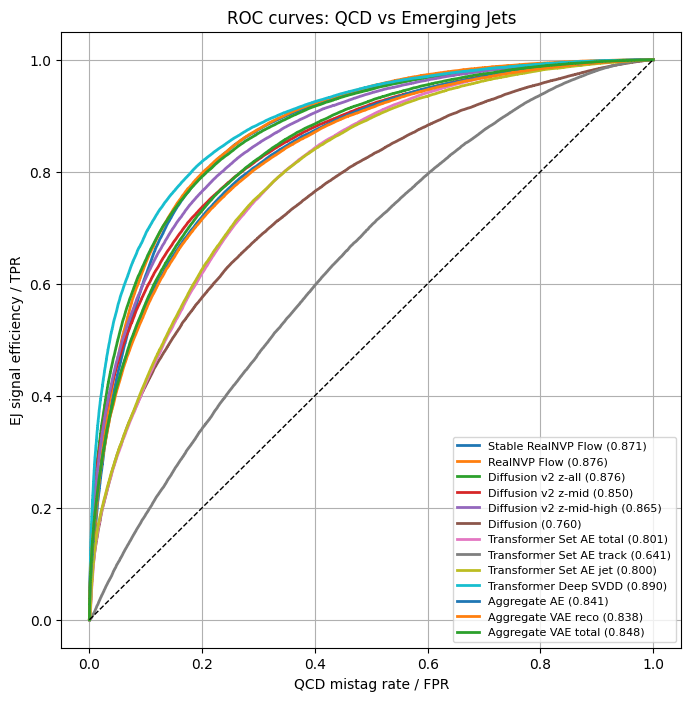

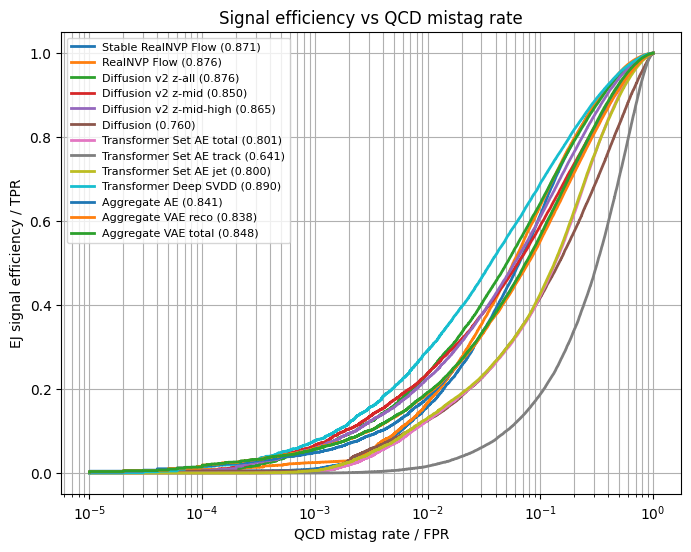

,model,best_auc,train_bg_best_auc,eff_at_0.3_mistag,eff_at_0.1_mistag,eff_at_0.05_mistag,eff_at_0.01_mistag,eff_at_0.001_mistag
0,Transformer Deep SVDD,0.889926,0.500055,0.884664,0.690006,0.559278,0.292390,0.076924
1,RealNVP Flow,0.876477,0.511928,0.876165,0.637130,0.464808,0.168265,0.025200
2,Diffusion v2 z-all,0.876389,NaN,0.868803,0.642640,0.498097,0.236977,0.056738
3,Stable RealNVP Flow,0.871314,0.502658,0.875207,0.615395,0.439113,0.159013,0.010026
4,Diffusion v2 z-mid-high,0.865065,NaN,0.850896,0.610164,0.468303,0.225475,0.059454
5,Diffusion v2 z-mid,0.849824,NaN,0.822226,0.589759,0.457925,0.238066,0.067166
6,Aggregate VAE total,0.847705,0.507620,0.823989,0.566243,0.420813,0.192593,0.057424
7,Aggregate AE,0.840991,0.508422,0.812957,0.559470,0.420830,0.180286,0.048957
8,Aggregate VAE reco,0.838279,0.508023,0.808749,0.553383,0.414157,0.188887,0.058531
9,Transformer Set AE total,0.801245,0.503636,0.753919,0.422464,0.294402,0.126419,0.004208


In [6]:
plt.figure(figsize=(8, 8))

for name, obj in loaded.items():
    met = obj["metrics"]
    plt.plot(met["fpr"], met["tpr"], linewidth=2, label=f"{name} ({met['best_auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
plt.xlabel("QCD mistag rate / FPR")
plt.ylabel("EJ signal efficiency / TPR")
plt.title("ROC curves: QCD vs Emerging Jets")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 6))

for name, obj in loaded.items():
    met = obj["metrics"]
    fpr = met["fpr"]
    tpr = met["tpr"]
    m = fpr > 0
    plt.plot(fpr[m], tpr[m], linewidth=2, label=f"{name} ({met['best_auc']:.3f})")

plt.xscale("log")
plt.xlabel("QCD mistag rate / FPR")
plt.ylabel("EJ signal efficiency / TPR")
plt.title("Signal efficiency vs QCD mistag rate")
plt.grid(True, which="both")
plt.legend(fontsize=8)
plt.show()


cols = [
    "model",
    "best_auc",
    "train_bg_best_auc",
    "eff_at_0.3_mistag",
    "eff_at_0.1_mistag",
    "eff_at_0.05_mistag",
    "eff_at_0.01_mistag",
    "eff_at_0.001_mistag",
]
display(df_results[cols])

## 6. Score distributions QCD vs EJ

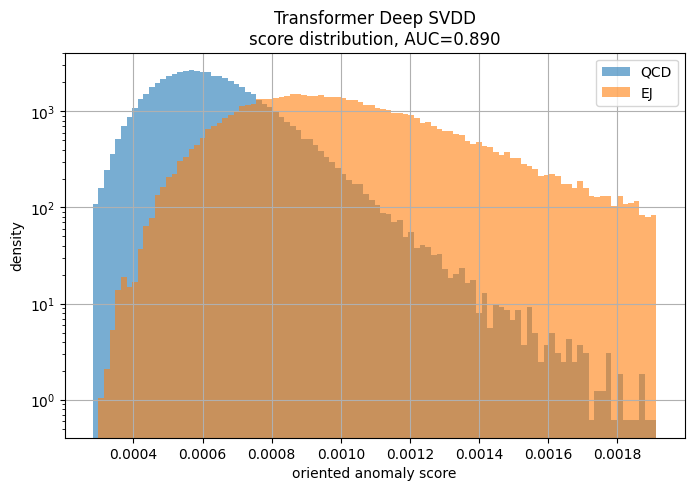

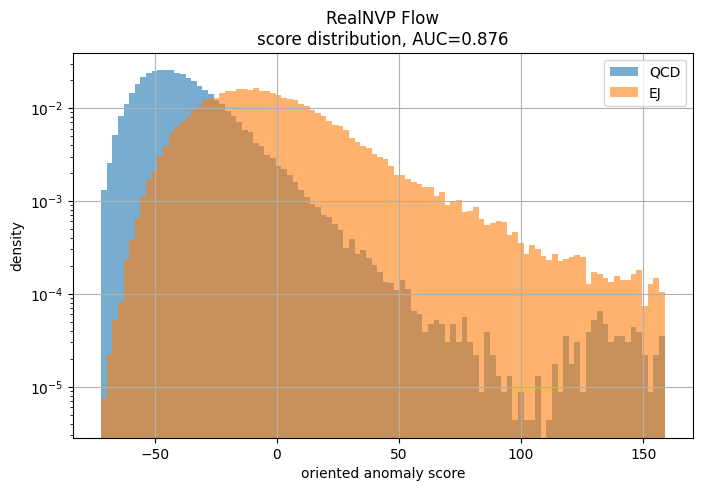

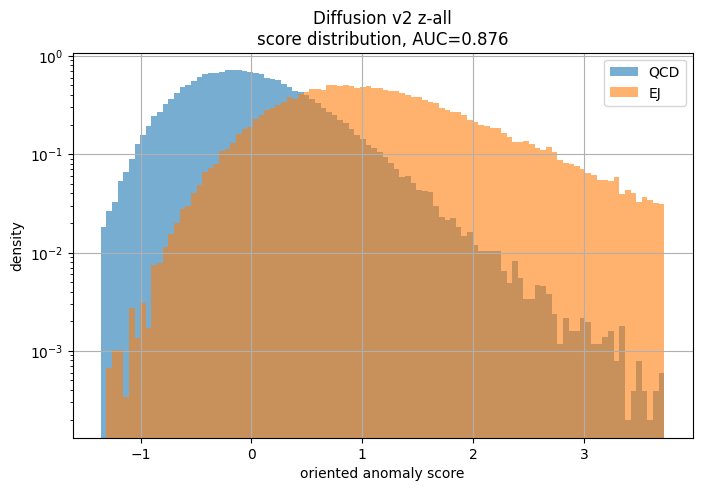

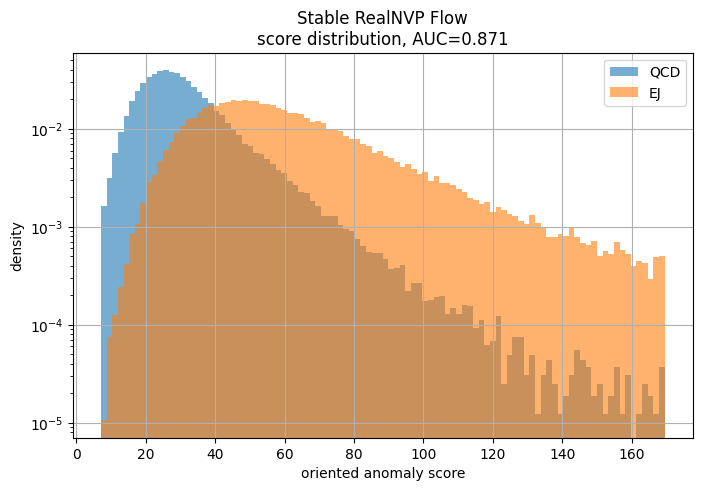

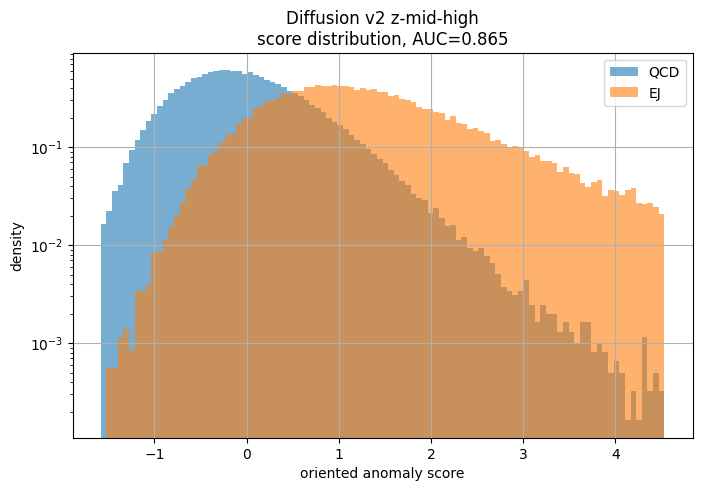

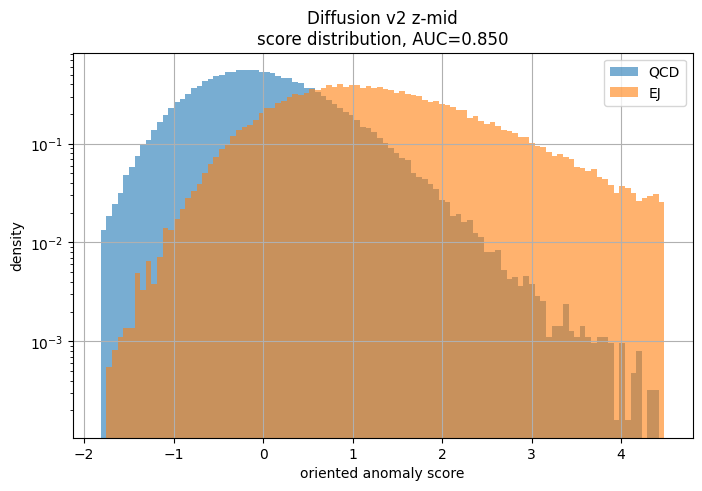

In [7]:
def plot_score_distribution(model_name, zoom_percentile=99):
    obj = loaded[model_name]
    met = obj["metrics"]

    bg = met["bg_oriented"]
    sig = met["sig_oriented"]

    all_scores = np.concatenate([bg, sig])
    lo = np.percentile(all_scores, 0.1)
    hi = np.percentile(all_scores, zoom_percentile)

    plt.figure(figsize=(8, 5))
    plt.hist(bg, bins=100, range=(lo, hi), density=True, alpha=0.6, label="QCD")
    plt.hist(sig, bins=100, range=(lo, hi), density=True, alpha=0.6, label="EJ")
    plt.yscale("log")
    plt.xlabel("oriented anomaly score")
    plt.ylabel("density")
    plt.title(f"{model_name}\nscore distribution, AUC={met['best_auc']:.3f}")
    plt.legend()
    plt.grid(True)
    plt.show()

for model_name in df_results["model"].head(min(6, len(df_results))).tolist():
    plot_score_distribution(model_name)

## 7. Train-vs-test-background check

,model,best_auc,train_bg_best_auc
0,Transformer Deep SVDD,0.889926,0.500055
11,Diffusion,0.760283,0.502115
12,Transformer Set AE track,0.640838,0.502604
3,Stable RealNVP Flow,0.871314,0.502658
10,Transformer Set AE jet,0.800241,0.503426
9,Transformer Set AE total,0.801245,0.503636
6,Aggregate VAE total,0.847705,0.507620
8,Aggregate VAE reco,0.838279,0.508023
7,Aggregate AE,0.840991,0.508422
1,RealNVP Flow,0.876477,0.511928


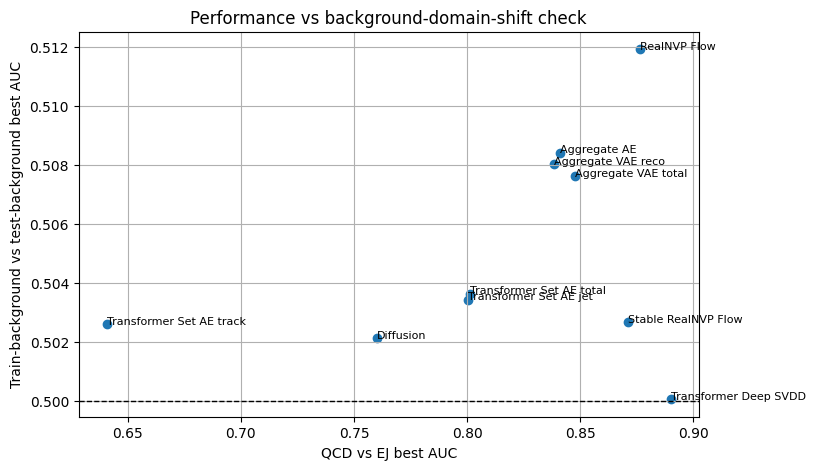

In [8]:
df_bgcheck = df_results[["model", "best_auc", "train_bg_best_auc"]].copy()
display(df_bgcheck.sort_values("train_bg_best_auc", ascending=True, na_position="last"))

valid = df_results.dropna(subset=["train_bg_best_auc"])

plt.figure(figsize=(8, 5))
plt.scatter(valid["best_auc"], valid["train_bg_best_auc"])

for _, row in valid.iterrows():
    plt.text(row["best_auc"], row["train_bg_best_auc"], row["model"], fontsize=8)

plt.axhline(0.5, linestyle="--", color="black", linewidth=1)
plt.xlabel("QCD vs EJ best AUC")
plt.ylabel("Train-background vs test-background best AUC")
plt.title("Performance vs background-domain-shift check")
plt.grid(True)
plt.show()

## 8. Supervised baseline su aggregate feature

In [9]:
def aggregate_track_features(X_tracks, mask):
    features = []

    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)

    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)

        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)

        features.extend([mean, std, median, q90, maxv])

    out = np.concatenate(features, axis=1)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def build_aggregate_matrix(X_jets, X_tracks, mask):
    return np.concatenate([X_jets.astype(np.float32), aggregate_track_features(X_tracks, mask)], axis=1)


supervised_results = {}

if DATASET_FILES is None:
    print("No processed dataset found. Skipping supervised aggregate baseline.")
else:
    data_bg = np.load(DATASET_FILES["test_background"], allow_pickle=True)
    data_sig = np.load(DATASET_FILES["test_signal"], allow_pickle=True)

    X_jets_bg = data_bg["X_jets"].astype(np.float32)
    X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
    mask_bg = data_bg["track_mask"].astype(bool)

    X_jets_sig = data_sig["X_jets"].astype(np.float32)
    X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
    mask_sig = data_sig["track_mask"].astype(bool)

    if "meta_isDisplaced" in data_sig:
        sig_filter = data_sig["meta_isDisplaced"] == 1
        X_jets_sig = X_jets_sig[sig_filter]
        X_tracks_sig = X_tracks_sig[sig_filter]
        mask_sig = mask_sig[sig_filter]

    bg_filter = mask_bg.sum(axis=1) > 0
    sig_filter = mask_sig.sum(axis=1) > 0

    X_jets_bg = X_jets_bg[bg_filter]
    X_tracks_bg = X_tracks_bg[bg_filter]
    mask_bg = mask_bg[bg_filter]

    X_jets_sig = X_jets_sig[sig_filter]
    X_tracks_sig = X_tracks_sig[sig_filter]
    mask_sig = mask_sig[sig_filter]

    A_bg = build_aggregate_matrix(X_jets_bg, X_tracks_bg, mask_bg)
    A_sig = build_aggregate_matrix(X_jets_sig, X_tracks_sig, mask_sig)

    X = np.concatenate([A_bg, A_sig], axis=0)
    y = np.concatenate([
        np.zeros(A_bg.shape[0], dtype=np.int64),
        np.ones(A_sig.shape[0], dtype=np.int64),
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=3000)

    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf.fit(X_train_s, y_train)
    proba = clf.predict_proba(X_test_s)[:, 1]

    auc_sup = roc_auc_score(y_test, proba)
    fpr_sup, tpr_sup, _ = roc_curve(y_test, proba)

    supervised_results["Aggregate logistic regression"] = {
        "auc": auc_sup,
        "fpr": fpr_sup,
        "tpr": tpr_sup,
        "clf": clf,
        "scaler": scaler,
        "A_bg": A_bg,
        "A_sig": A_sig,
    }

    print("Supervised aggregate logistic regression AUC:", auc_sup)

Supervised aggregate logistic regression AUC: 0.9946137129976342


## 9. Supervised baseline su latent embeddings

In [10]:
latent_candidates = [
    {
        "name": "Transformer Set AE latent",
        "path": Path("outputs_transformer_set/transformer_set_scores.npz"),
        "bg_key": "Z_bg",
        "sig_key": "Z_sig",
    },
    {
        "name": "Transformer Deep SVDD latent",
        "path": Path("outputs_transformer_svdd/transformer_deep_svdd_scores.npz"),
        "bg_key": "Z_bg",
        "sig_key": "Z_sig",
    },
    {
        "name": "GNN latent",
        "path": Path("outputs_gnn/gnn_constituent_scores.npz"),
        "bg_key": "Z_bg",
        "sig_key": "Z_sig",
    },
]

latent_results = {}

for item in latent_candidates:
    if not item["path"].exists():
        print("Missing latent file:", item["name"], item["path"])
        continue

    data = np.load(item["path"], allow_pickle=True)

    if item["bg_key"] not in data or item["sig_key"] not in data:
        print("Missing latent keys:", item["name"])
        continue

    Z_bg = np.asarray(data[item["bg_key"]], dtype=np.float32)
    Z_sig = np.asarray(data[item["sig_key"]], dtype=np.float32)

    X = np.concatenate([Z_bg, Z_sig], axis=0)
    y = np.concatenate([
        np.zeros(Z_bg.shape[0], dtype=np.int64),
        np.ones(Z_sig.shape[0], dtype=np.int64),
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    clf = LogisticRegression(max_iter=3000)

    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf.fit(X_train_s, y_train)
    proba = clf.predict_proba(X_test_s)[:, 1]

    auc_lat = roc_auc_score(y_test, proba)
    fpr_lat, tpr_lat, _ = roc_curve(y_test, proba)

    latent_results[item["name"]] = {
        "auc": auc_lat,
        "fpr": fpr_lat,
        "tpr": tpr_lat,
        "Z_bg": Z_bg,
        "Z_sig": Z_sig,
    }

    print(item["name"], "AUC:", auc_lat)

Transformer Set AE latent AUC: 0.9923529648465882
Transformer Deep SVDD latent AUC: 0.9859243204977738
Missing latent file: GNN latent outputs_gnn\gnn_constituent_scores.npz


## 10. ROC: unsupervised vs supervised

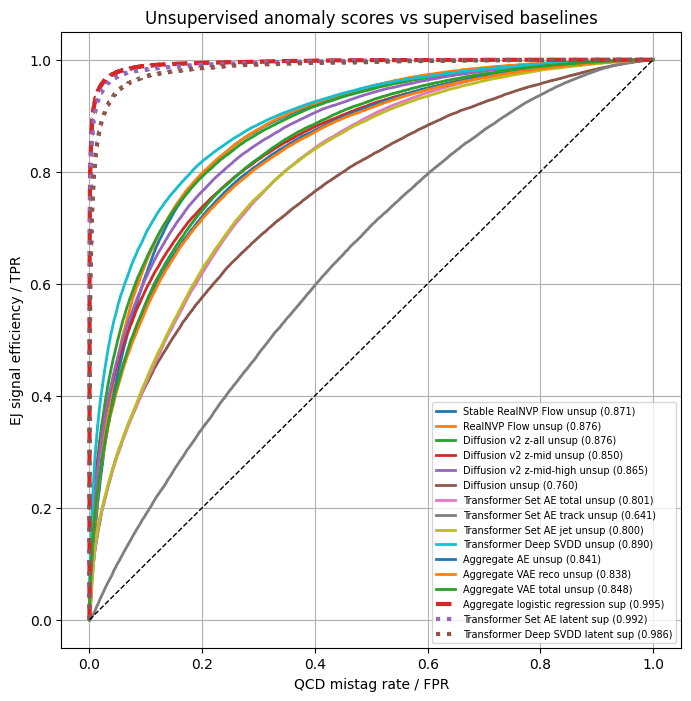

In [11]:
plt.figure(figsize=(8, 8))

for name, obj in loaded.items():
    met = obj["metrics"]
    plt.plot(met["fpr"], met["tpr"], linewidth=2, label=f"{name} unsup ({met['best_auc']:.3f})")

for name, obj in supervised_results.items():
    plt.plot(obj["fpr"], obj["tpr"], linestyle="--", linewidth=3, label=f"{name} sup ({obj['auc']:.3f})")

for name, obj in latent_results.items():
    plt.plot(obj["fpr"], obj["tpr"], linestyle=":", linewidth=3, label=f"{name} sup ({obj['auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
plt.xlabel("QCD mistag rate / FPR")
plt.ylabel("EJ signal efficiency / TPR")
plt.title("Unsupervised anomaly scores vs supervised baselines")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()

## 11. Interpretabilità: top feature aggregate supervisionate

,feature,coef,abs_coef
12,ECF1_clusterSoftDrop,6.317301,6.317301
0,pt,-6.171293,6.171293
6,D2_clusterSoftDrop,-5.048862,5.048862
13,ECF2_clusterSoftDrop,-3.798409,3.798409
40,radiusOfFirstHit_mean,3.089101,3.089101
10,Tau21_clusterSoftDrop,2.843060,2.843060
2,mass,2.730199,2.730199
14,n_valid_tracks,-2.594203,2.594203
5,C2_clusterSoftDrop,2.190322,2.190322
8,Tau2_clusterSoftDrop,1.937743,1.937743


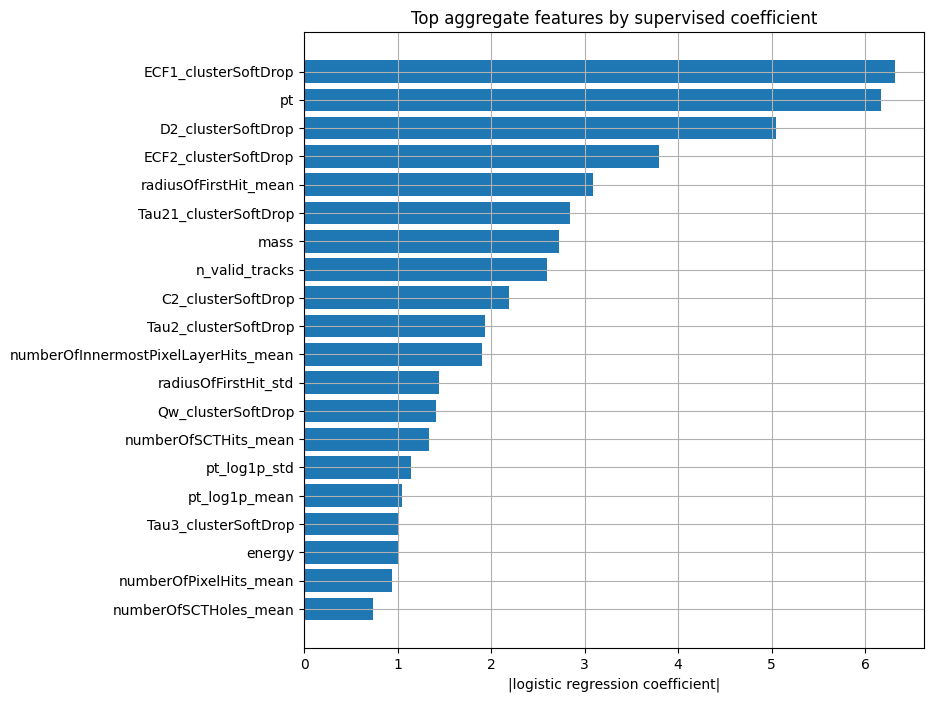

Saved: outputs_task3_v2\supervised_feature_coefficients.csv


In [12]:
if DATASET_FILES is None or "Aggregate logistic regression" not in supervised_results:
    print("Skipping feature interpretability.")
else:
    data_bg = np.load(DATASET_FILES["test_background"], allow_pickle=True)

    jet_feature_names = list(data_bg["jet_feature_names"])
    track_feature_names = list(data_bg["track_feature_names"])

    feature_names = []
    feature_names.extend(jet_feature_names)
    feature_names.append("n_valid_tracks")

    for feat in track_feature_names:
        feature_names.extend([
            f"{feat}_mean",
            f"{feat}_std",
            f"{feat}_median",
            f"{feat}_q90",
            f"{feat}_max",
        ])

    clf = supervised_results["Aggregate logistic regression"]["clf"]
    coefs = clf.coef_[0]

    df_coef = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs),
    }).sort_values("abs_coef", ascending=False)

    display(df_coef.head(30))

    plt.figure(figsize=(8, 8))
    top = df_coef.head(20).iloc[::-1]
    plt.barh(top["feature"], top["abs_coef"])
    plt.xlabel("|logistic regression coefficient|")
    plt.title("Top aggregate features by supervised coefficient")
    plt.grid(True)
    plt.show()

    df_coef.to_csv(OUTPUT_DIR / "supervised_feature_coefficients.csv", index=False)
    print("Saved:", OUTPUT_DIR / "supervised_feature_coefficients.csv")

## 12. PCA latent space

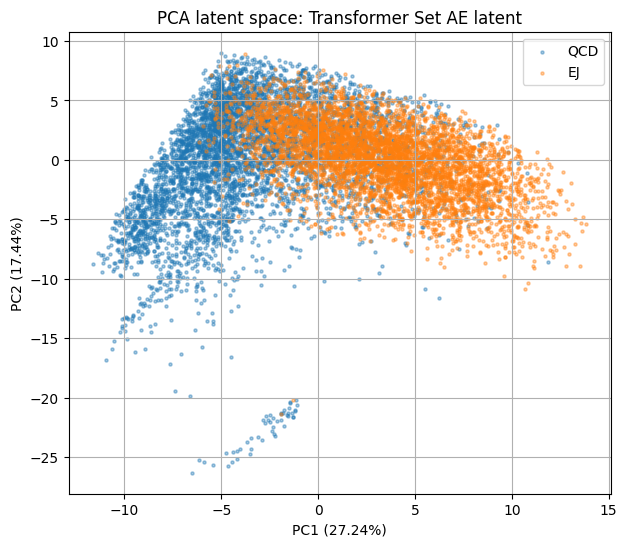

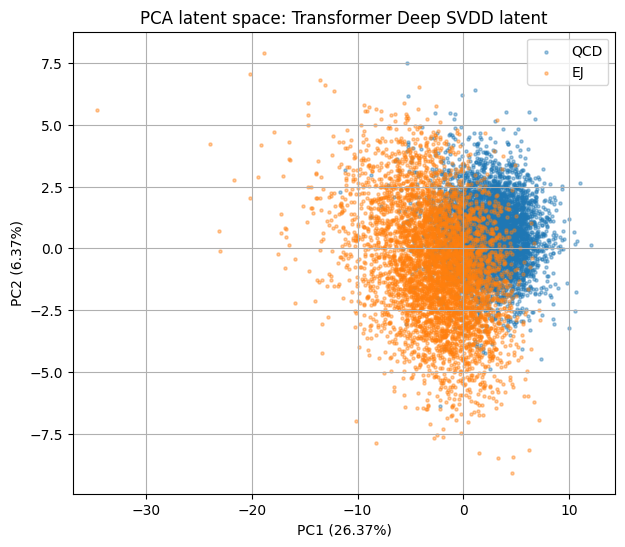

In [13]:
def pca_latent_plot(name, Z_bg, Z_sig, max_points=5000):
    rng = np.random.default_rng(42)

    n_bg = min(max_points, Z_bg.shape[0])
    n_sig = min(max_points, Z_sig.shape[0])

    idx_bg = rng.choice(Z_bg.shape[0], size=n_bg, replace=False)
    idx_sig = rng.choice(Z_sig.shape[0], size=n_sig, replace=False)

    X = np.concatenate([Z_bg[idx_bg], Z_sig[idx_sig]], axis=0)
    y = np.concatenate([
        np.zeros(n_bg, dtype=np.int64),
        np.ones(n_sig, dtype=np.int64),
    ])

    Xs = StandardScaler().fit_transform(X)

    pca = PCA(n_components=2)
    X2 = pca.fit_transform(Xs)

    plt.figure(figsize=(7, 6))
    plt.scatter(X2[y == 0, 0], X2[y == 0, 1], s=5, alpha=0.4, label="QCD")
    plt.scatter(X2[y == 1, 0], X2[y == 1, 1], s=5, alpha=0.4, label="EJ")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.title(f"PCA latent space: {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

for name, obj in latent_results.items():
    pca_latent_plot(name, obj["Z_bg"], obj["Z_sig"])

## 13. Truth-level dark pion information

In [14]:
def build_signal_filter_from_h5(signal_h5):
    with h5py.File(signal_h5, "r") as f:
        jets = f["jets"]
        tracks = f["tracks"]

        n = jets.shape[0]
        filt = np.ones(n, dtype=bool)

        if "isDisplaced" in jets.dtype.names:
            filt = filt & (jets["isDisplaced"][:] == 1)

        if "valid" in tracks.dtype.names:
            track_mask = tracks["valid"][:].astype(bool)
            filt = filt & (track_mask.sum(axis=1) > 0)

    return filt


def load_truth_dark_pions(signal_h5, signal_filter=None):
    with h5py.File(signal_h5, "r") as f:
        if "truth_dark_pions" not in f:
            raise KeyError("truth_dark_pions not found.")

        truth = f["truth_dark_pions"]
        valid = truth["valid"][:].astype(bool)

        if signal_filter is not None:
            valid = valid[signal_filter]

        out = {}

        fields = ["mass", "Lxy", "Lxy_prod", "pt", "energy", "dr", "deta", "dphi"]

        for field in fields:
            if field not in truth.dtype.names:
                continue

            x = truth[field][:].astype(np.float32)

            if signal_filter is not None:
                x = x[signal_filter]

            x_valid = np.where(valid, x, np.nan)

            out[f"{field}_mean"] = np.nanmean(x_valid, axis=1)
            out[f"{field}_median"] = np.nanmedian(x_valid, axis=1)
            out[f"{field}_min"] = np.nanmin(x_valid, axis=1)
            out[f"{field}_max"] = np.nanmax(x_valid, axis=1)
            out[f"{field}_q90"] = np.nanpercentile(x_valid, 90, axis=1)

        out["n_truth_dark_pions"] = valid.sum(axis=1)

    df = pd.DataFrame(out)
    df = df.replace([np.inf, -np.inf], np.nan)

    return df


if SIGNAL_H5.exists():
    signal_filter_truth = build_signal_filter_from_h5(SIGNAL_H5)
    df_truth = load_truth_dark_pions(SIGNAL_H5, signal_filter=signal_filter_truth)

    print("Signal truth selected rows:", df_truth.shape)
    display(df_truth.describe().T)
    print("Truth columns:", list(df_truth.columns))

    df_truth.to_csv(OUTPUT_DIR / "truth_dark_pion_per_jet.csv", index=False)
    print("Saved:", OUTPUT_DIR / "truth_dark_pion_per_jet.csv")
else:
    df_truth = None
    print("SIGNAL_H5 not found. Skipping truth-level sensitivity.")

C:\Users\andre\AppData\Local\Temp\ipykernel_33872\977337961.py:45: RuntimeWarning: Mean of empty slice
  out[f"{field}_mean"] = np.nanmean(x_valid, axis=1)
C:\Users\andre\AppData\Local\Temp\ipykernel_33872\977337961.py:46: RuntimeWarning: All-NaN slice encountered
  out[f"{field}_median"] = np.nanmedian(x_valid, axis=1)
C:\Users\andre\AppData\Local\Temp\ipykernel_33872\977337961.py:47: RuntimeWarning: All-NaN slice encountered
  out[f"{field}_min"] = np.nanmin(x_valid, axis=1)
C:\Users\andre\AppData\Local\Temp\ipykernel_33872\977337961.py:48: RuntimeWarning: All-NaN slice encountered
  out[f"{field}_max"] = np.nanmax(x_valid, axis=1)
c:\Users\andre\Desktop\You_better_code\advanceml\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Signal truth selected rows: (59643, 41)


,count,mean,std,min,25%,50%,75%,max
mass_mean,59000.0,10000.000000,0.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mass_median,59000.0,10000.000000,0.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mass_min,59000.0,10000.000000,0.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mass_max,59000.0,10000.000000,0.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
mass_q90,59000.0,10000.000000,0.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04
Lxy_mean,59000.0,116.538635,45.402157,0.103367,86.369499,114.501831,144.187607,2.999960e+02
Lxy_median,59000.0,109.364845,55.533142,0.103367,67.631119,102.764267,144.654053,2.999960e+02
Lxy_min,59000.0,40.464520,46.849598,0.026981,9.435519,24.038025,53.159710,2.999960e+02
Lxy_max,59000.0,208.133286,69.545708,0.103367,163.746033,223.147873,265.476410,2.999999e+02
Lxy_q90,59000.0,186.226456,62.743797,0.103367,146.031570,195.937103,234.781097,2.999960e+02


Truth columns: ['mass_mean', 'mass_median', 'mass_min', 'mass_max', 'mass_q90', 'Lxy_mean', 'Lxy_median', 'Lxy_min', 'Lxy_max', 'Lxy_q90', 'Lxy_prod_mean', 'Lxy_prod_median', 'Lxy_prod_min', 'Lxy_prod_max', 'Lxy_prod_q90', 'pt_mean', 'pt_median', 'pt_min', 'pt_max', 'pt_q90', 'energy_mean', 'energy_median', 'energy_min', 'energy_max', 'energy_q90', 'dr_mean', 'dr_median', 'dr_min', 'dr_max', 'dr_q90', 'deta_mean', 'deta_median', 'deta_min', 'deta_max', 'deta_q90', 'dphi_mean', 'dphi_median', 'dphi_min', 'dphi_max', 'dphi_q90', 'n_truth_dark_pions']
Saved: outputs_task3_v2\truth_dark_pion_per_jet.csv


## 14. Sensitivity vs truth-level mass and Lxy


Model: Transformer Deep SVDD
[SKIP] Transformer Deep SVDD / mass_median: constant variable.
[SKIP] Transformer Deep SVDD / mass_mean: constant variable.


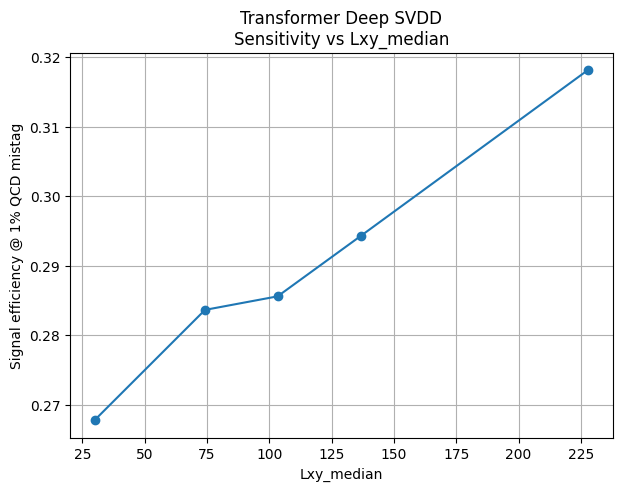

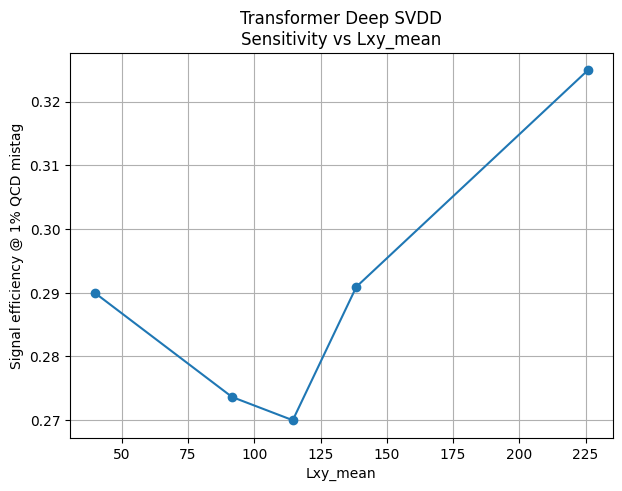

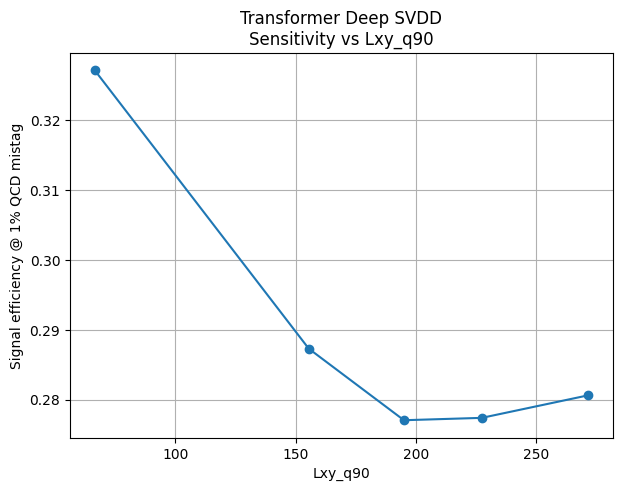

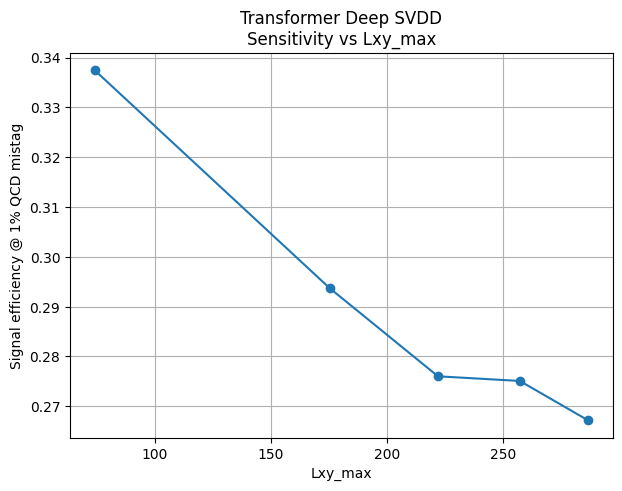

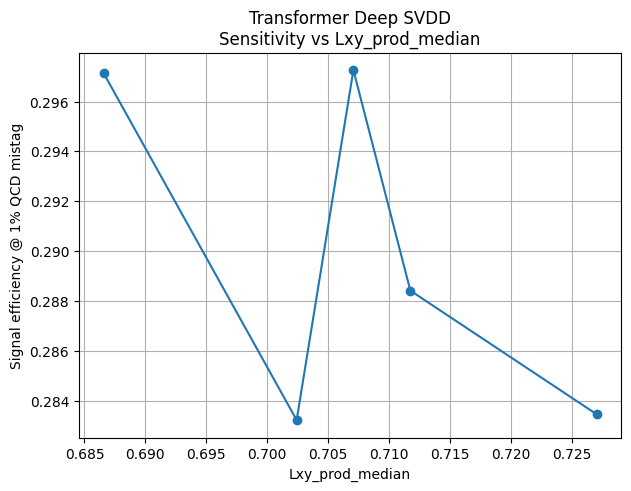

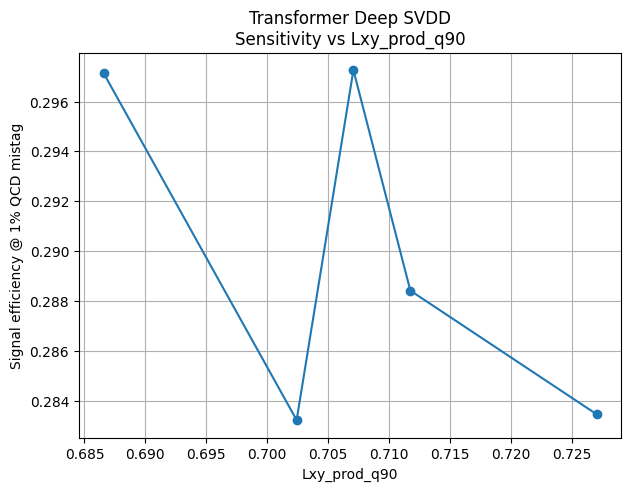

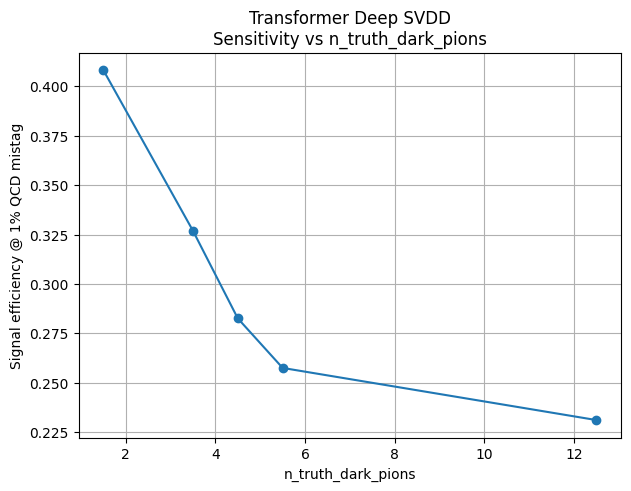


Model: RealNVP Flow
[SKIP] RealNVP Flow / mass_median: constant variable.
[SKIP] RealNVP Flow / mass_mean: constant variable.


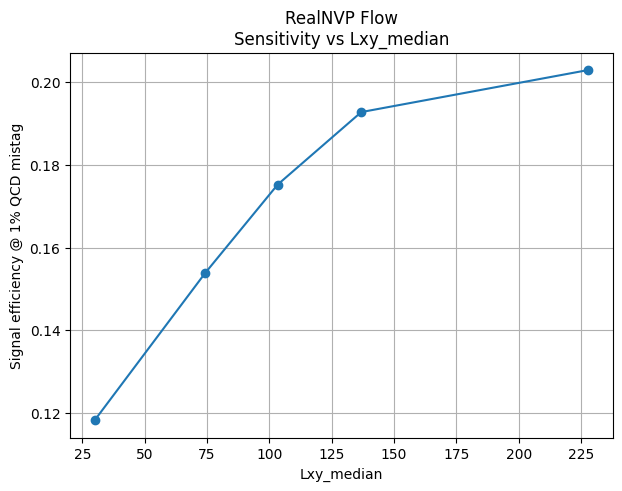

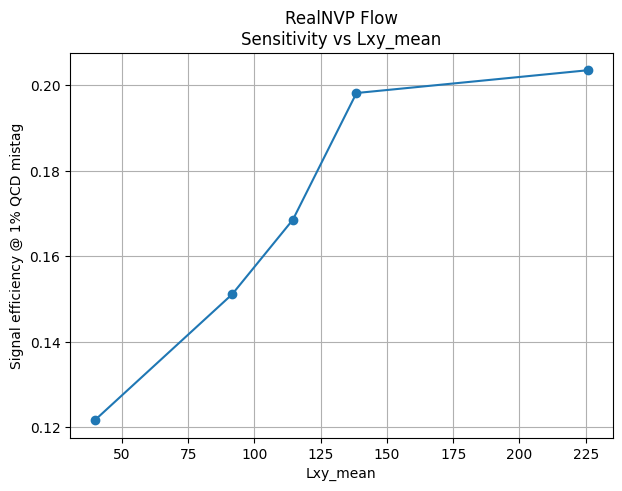

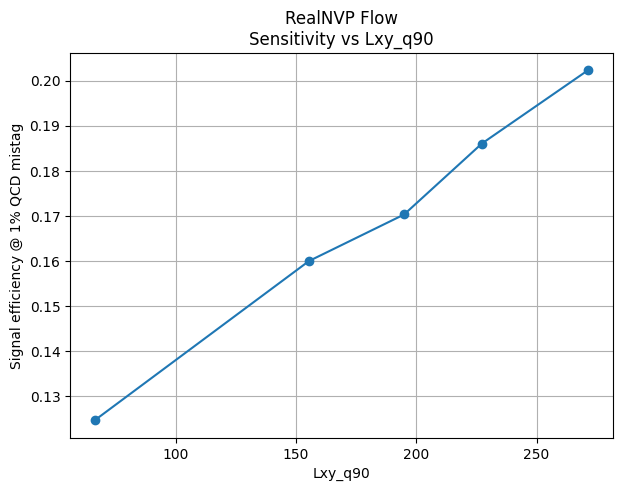

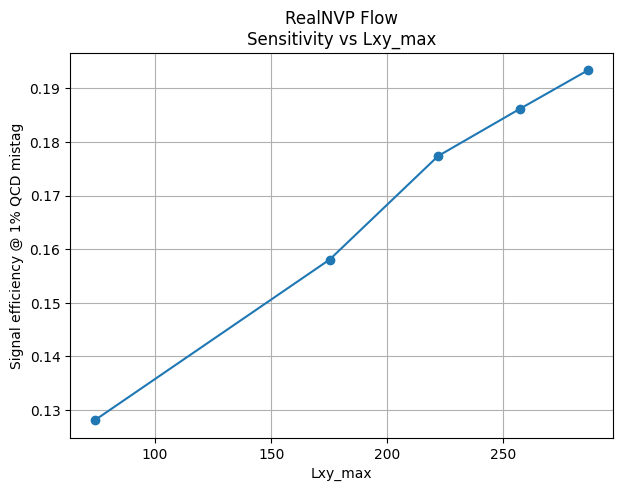

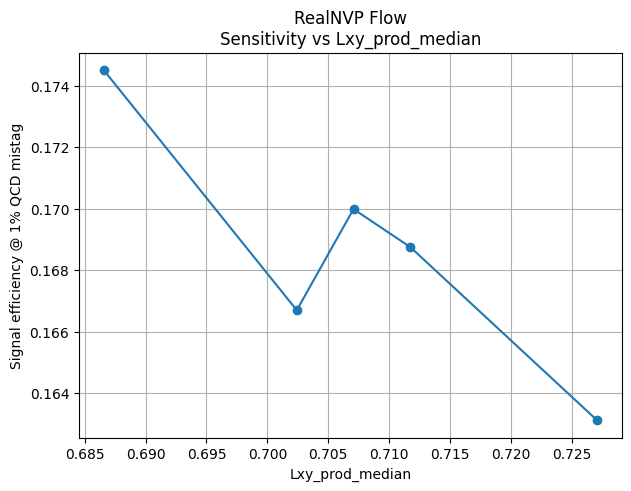

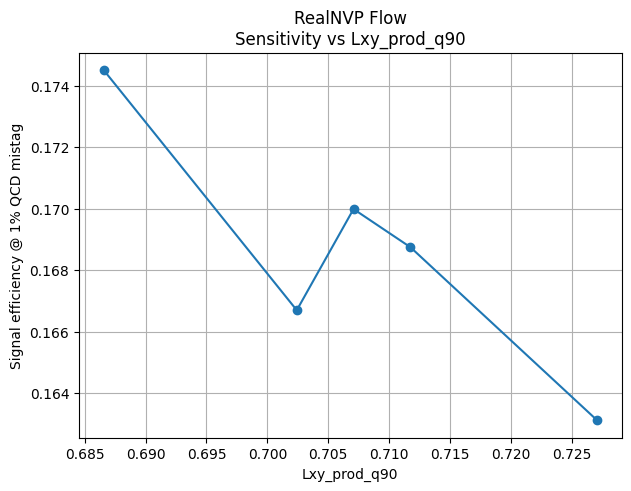

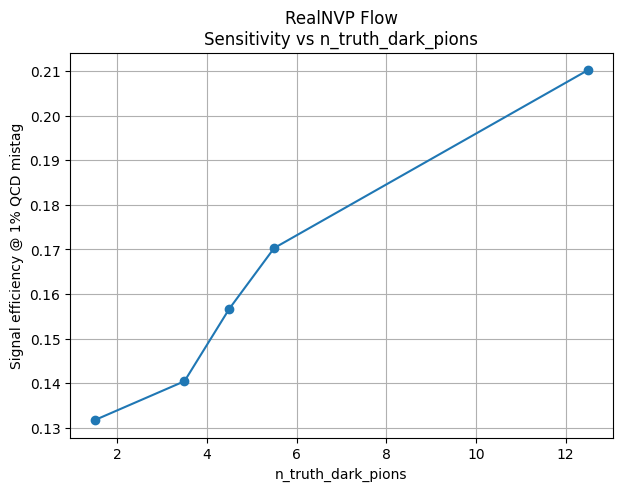


Model: Diffusion v2 z-all
[SKIP] Diffusion v2 z-all / mass_median: constant variable.
[SKIP] Diffusion v2 z-all / mass_mean: constant variable.


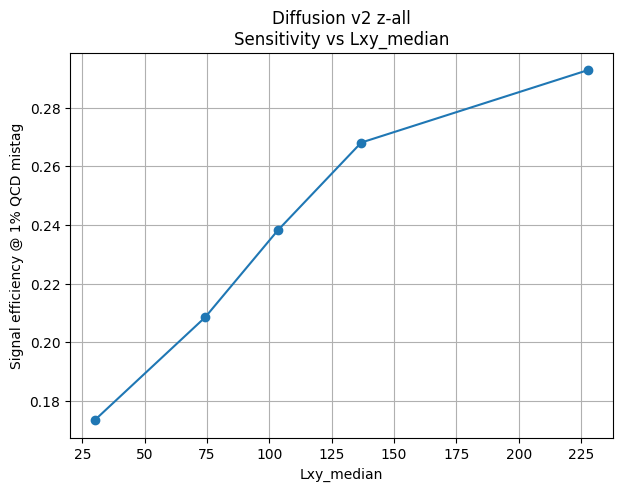

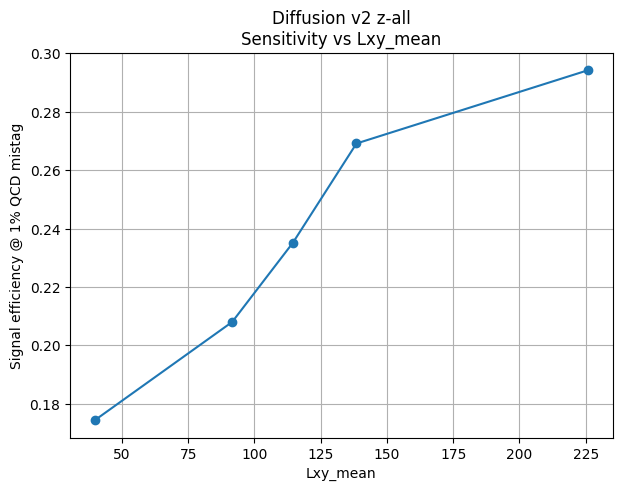

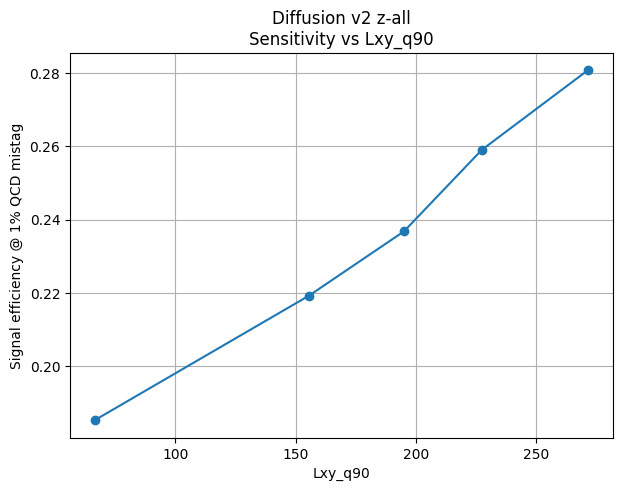

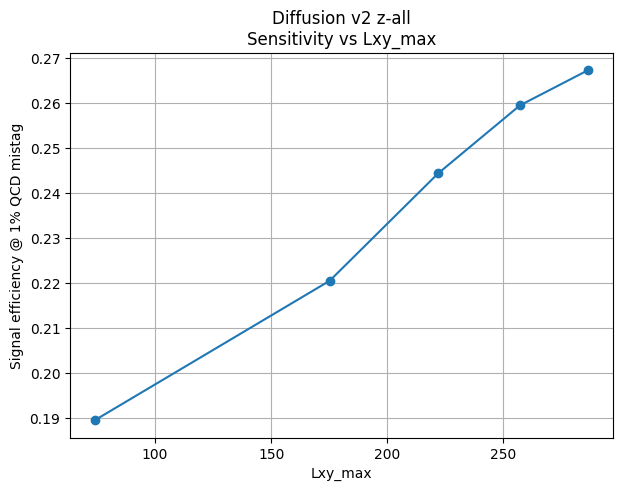

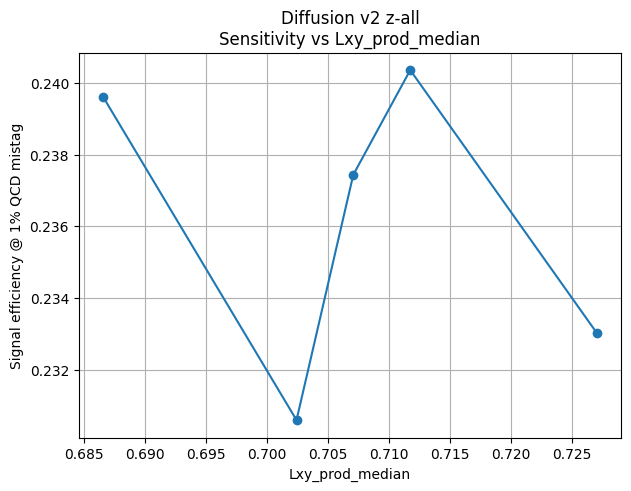

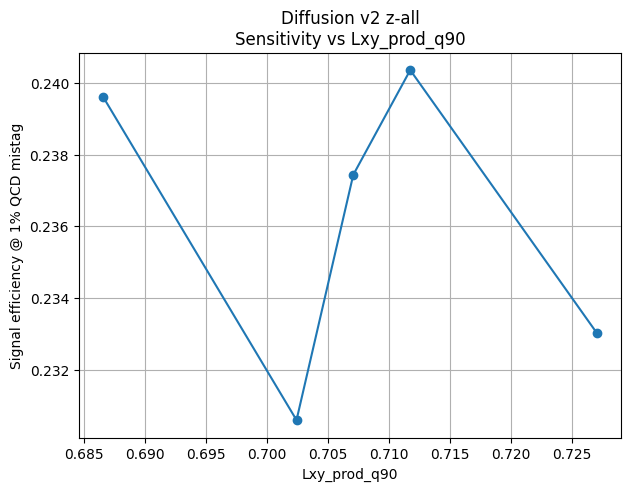

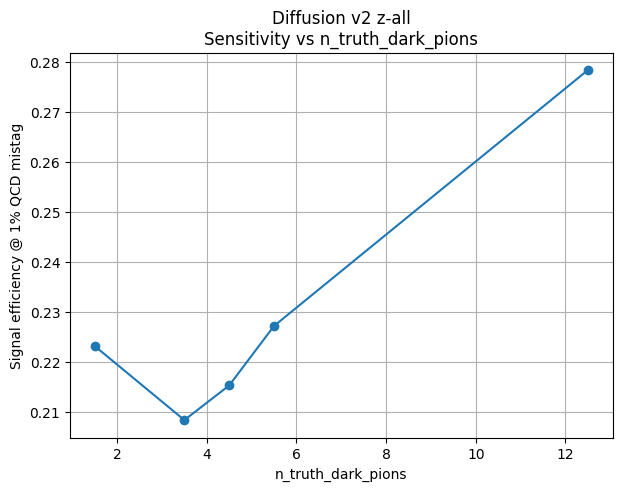


Model: Stable RealNVP Flow
[SKIP] Stable RealNVP Flow / mass_median: constant variable.
[SKIP] Stable RealNVP Flow / mass_mean: constant variable.


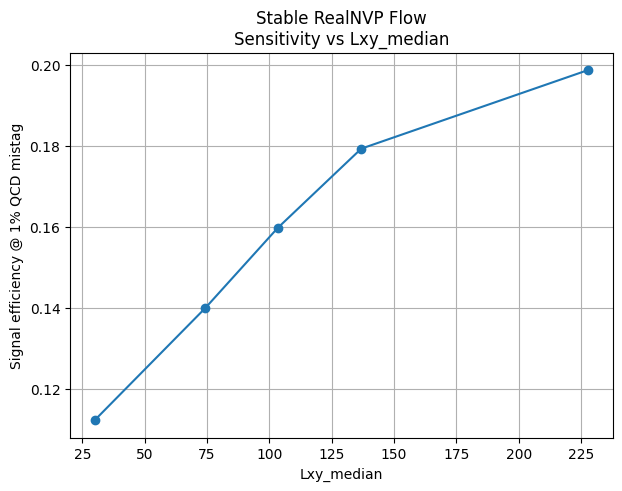

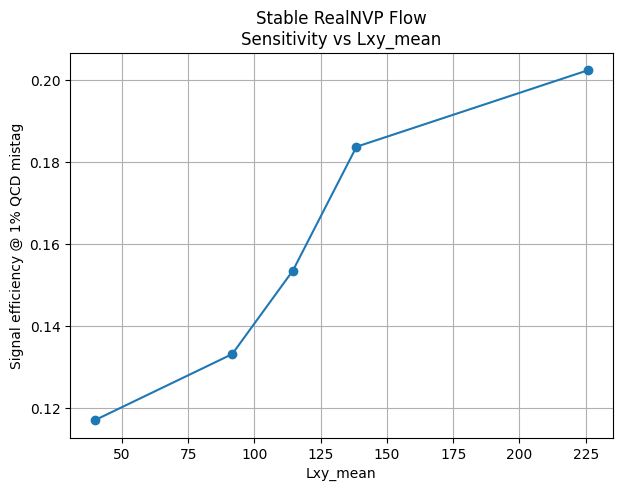

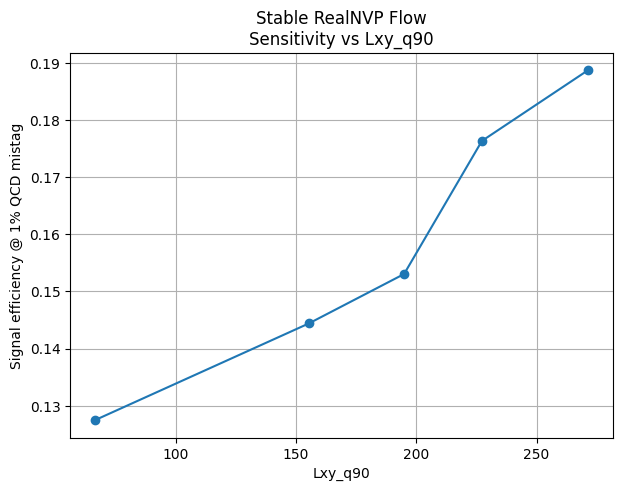

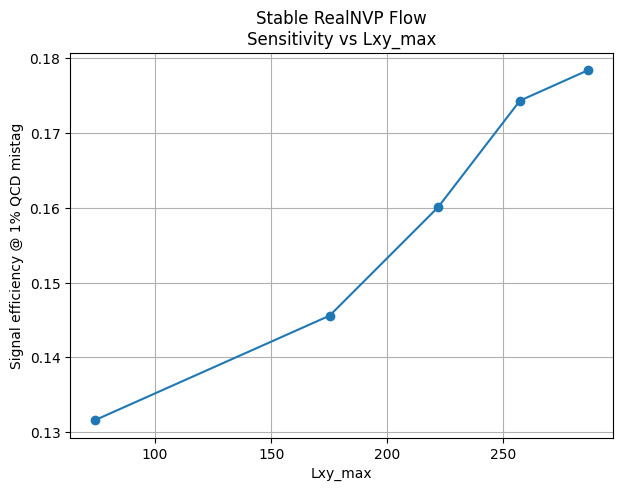

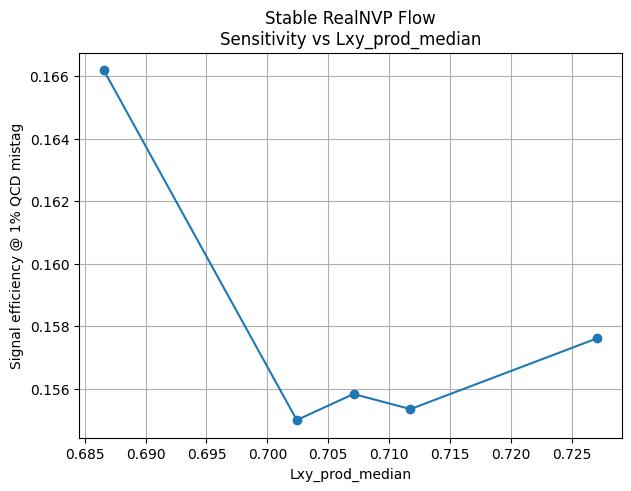

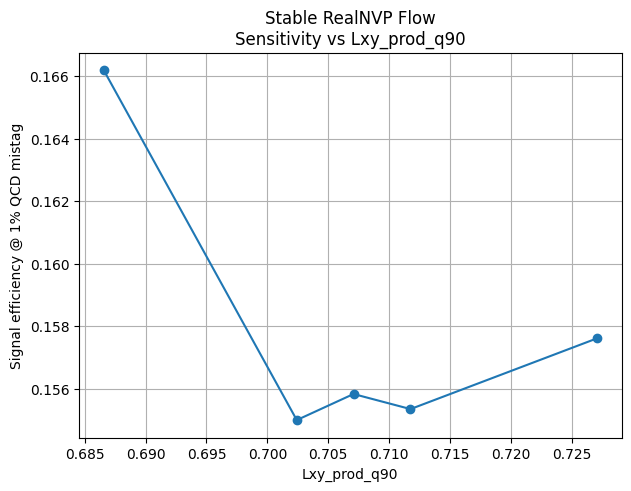

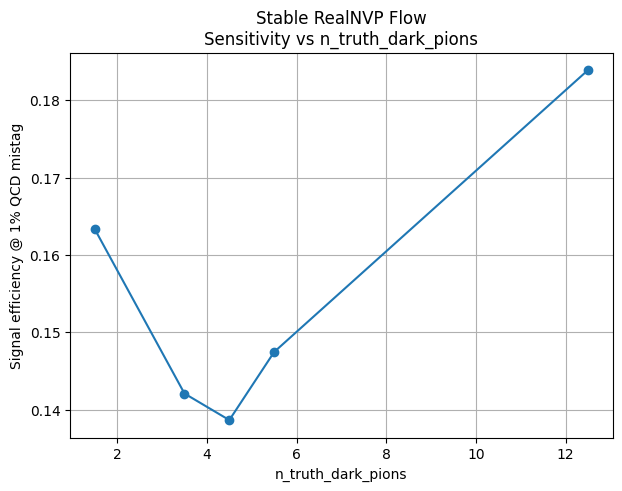


Model: Diffusion v2 z-mid-high
[SKIP] Diffusion v2 z-mid-high / mass_median: constant variable.
[SKIP] Diffusion v2 z-mid-high / mass_mean: constant variable.


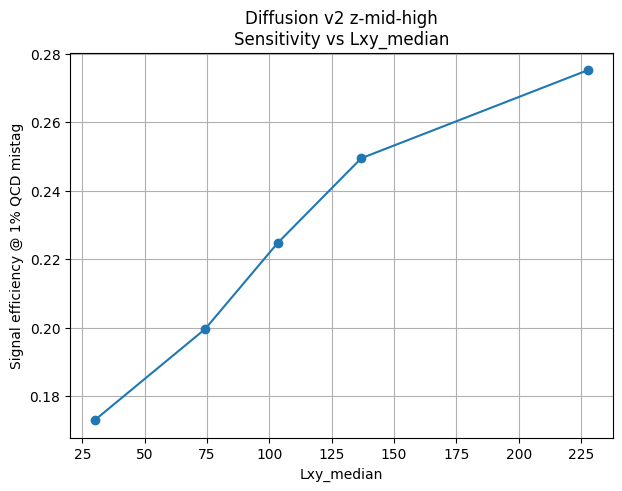

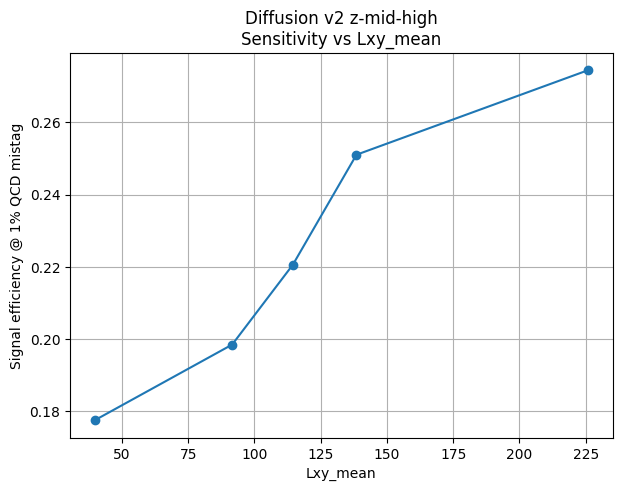

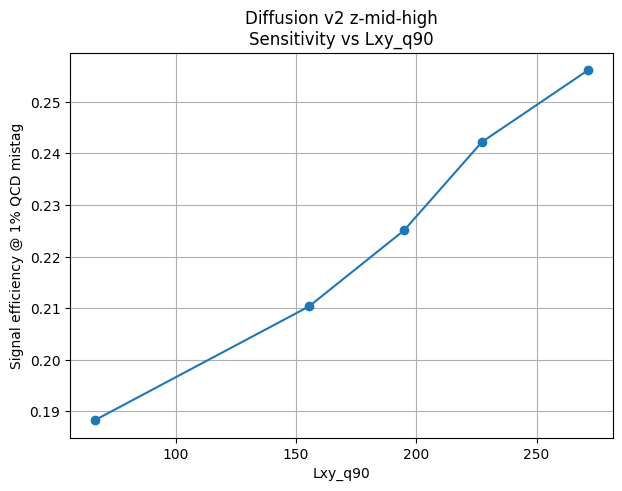

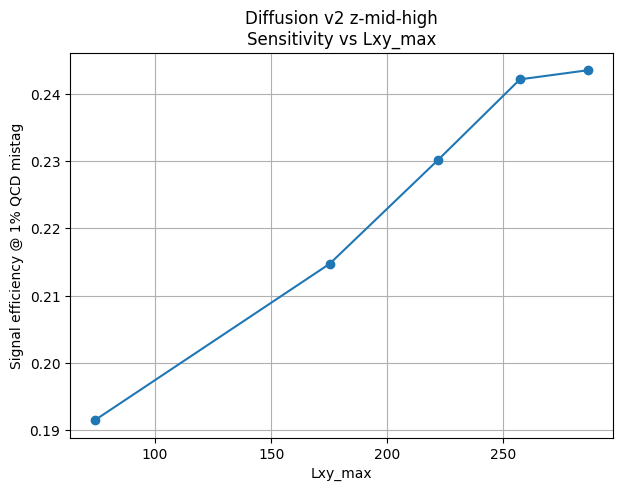

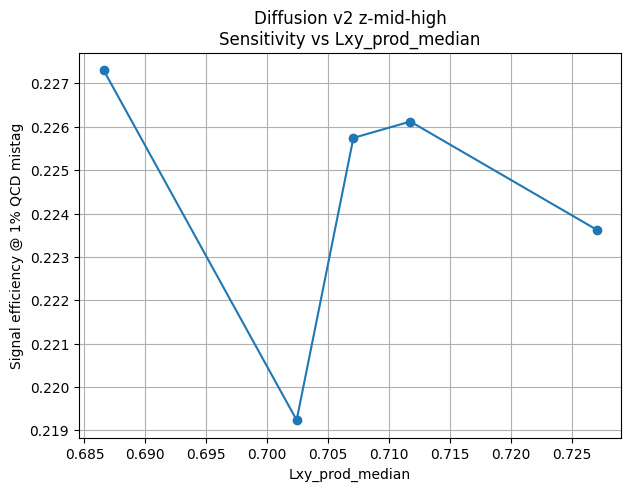

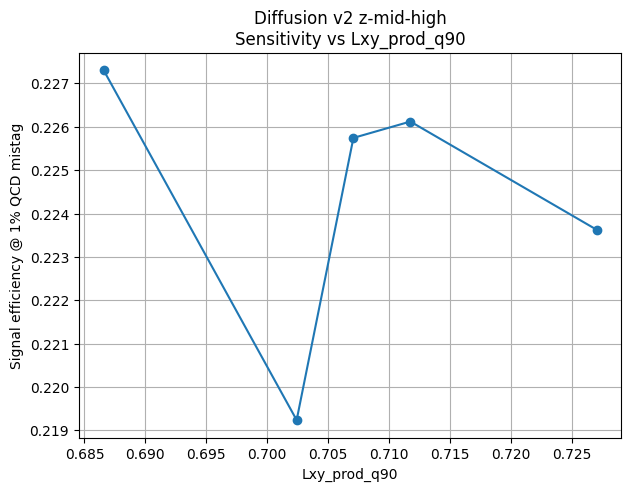

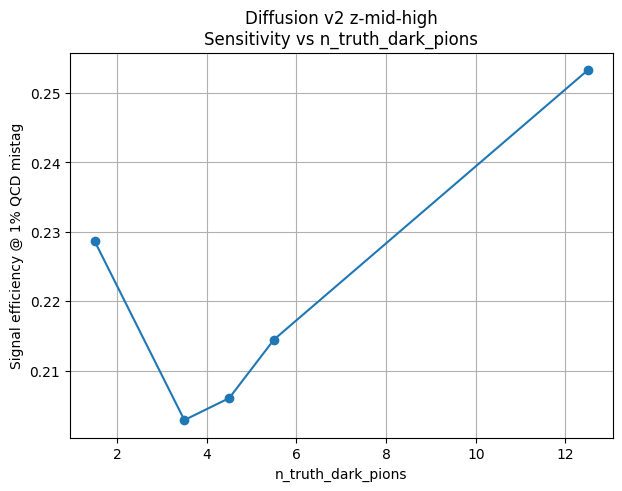

,model,variable,mistag,threshold,bin_low,bin_high,bin_center,n_signal,signal_efficiency
0,Transformer Deep SVDD,Lxy_median,0.01,0.001165,0.103367,59.823020,29.963194,11800,0.267797
1,Transformer Deep SVDD,Lxy_median,0.01,0.001165,59.823020,88.623120,74.223070,11800,0.283644
2,Transformer Deep SVDD,Lxy_median,0.01,0.001165,88.623120,118.071744,103.347432,11800,0.285593
3,Transformer Deep SVDD,Lxy_median,0.01,0.001165,118.071744,155.656149,136.863947,11800,0.294322
4,Transformer Deep SVDD,Lxy_median,0.01,0.001165,155.656149,299.996002,227.826076,11800,0.318136
5,Transformer Deep SVDD,Lxy_mean,0.01,0.001165,0.103367,79.471892,39.787629,11800,0.290000
6,Transformer Deep SVDD,Lxy_mean,0.01,0.001165,79.471892,103.760516,91.616204,11800,0.273644
7,Transformer Deep SVDD,Lxy_mean,0.01,0.001165,103.760516,125.283998,114.522257,11800,0.270000
8,Transformer Deep SVDD,Lxy_mean,0.01,0.001165,125.283998,151.742670,138.513334,11800,0.290932
9,Transformer Deep SVDD,Lxy_mean,0.01,0.001165,151.742670,299.996002,225.869336,11800,0.324915


Saved: outputs_task3_v2\truth_dark_pion_sensitivity.csv


In [17]:
def efficiency_vs_variable(
    variable,
    sig_scores,
    bg_scores,
    truth_df,
    mistag=0.01,
    n_bins=5,
    model_name="model",
):
    """
    Calcola signal efficiency in bin di una variabile truth-level.
    Ritorna un DataFrame vuoto se la variabile non è plottabile.
    """

    columns = [
        "model",
        "variable",
        "mistag",
        "threshold",
        "bin_low",
        "bin_high",
        "bin_center",
        "n_signal",
        "signal_efficiency",
    ]

    if variable not in truth_df.columns:
        print(f"[SKIP] {variable}: column not found.")
        return pd.DataFrame(columns=columns)

    n = min(len(sig_scores), len(truth_df))

    sig_scores = np.asarray(sig_scores[:n], dtype=np.float64)
    bg_scores = np.asarray(bg_scores, dtype=np.float64)
    values = np.asarray(truth_df[variable].values[:n], dtype=np.float64)

    valid = np.isfinite(values) & np.isfinite(sig_scores)

    values = values[valid]
    sig_scores = sig_scores[valid]

    if len(values) == 0:
        print(f"[SKIP] {model_name} / {variable}: no finite values.")
        return pd.DataFrame(columns=columns)

    if len(np.unique(values)) < 2:
        print(f"[SKIP] {model_name} / {variable}: constant variable.")
        return pd.DataFrame(columns=columns)

    bg_scores = bg_scores[np.isfinite(bg_scores)]

    if len(bg_scores) == 0:
        print(f"[SKIP] {model_name} / {variable}: no finite background scores.")
        return pd.DataFrame(columns=columns)

    threshold = np.quantile(bg_scores, 1.0 - mistag)

    edges = np.quantile(values, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)

    if len(edges) < 2:
        print(f"[SKIP] {model_name} / {variable}: cannot build bins.")
        return pd.DataFrame(columns=columns)

    rows = []

    for i in range(len(edges) - 1):
        lo = edges[i]
        hi = edges[i + 1]

        if i == len(edges) - 2:
            mask = (values >= lo) & (values <= hi)
        else:
            mask = (values >= lo) & (values < hi)

        if mask.sum() == 0:
            continue

        eff = np.mean(sig_scores[mask] >= threshold)

        rows.append({
            "model": model_name,
            "variable": variable,
            "mistag": mistag,
            "threshold": threshold,
            "bin_low": lo,
            "bin_high": hi,
            "bin_center": 0.5 * (lo + hi),
            "n_signal": int(mask.sum()),
            "signal_efficiency": float(eff),
        })

    return pd.DataFrame(rows, columns=columns)
truth_sensitivity_rows = []

if df_truth is None:
    print("No truth dataframe available.")
else:
    top_for_truth = df_results["model"].head(min(5, len(df_results))).tolist()

    truth_variables = [
        "mass_median",
        "mass_mean",
        "Lxy_median",
        "Lxy_mean",
        "Lxy_q90",
        "Lxy_max",
        "Lxy_prod_median",
        "Lxy_prod_q90",
        "n_truth_dark_pions",
    ]

    truth_variables = [v for v in truth_variables if v in df_truth.columns]

    for model_name in top_for_truth:
        obj = loaded[model_name]

        bg_scores = obj["metrics"]["bg_oriented"]
        sig_scores = obj["metrics"]["sig_oriented"]

        print("\nModel:", model_name)

        for var in truth_variables:
            df_var = efficiency_vs_variable(
                variable=var,
                sig_scores=sig_scores,
                bg_scores=bg_scores,
                truth_df=df_truth,
                mistag=0.01,
                n_bins=5,
                model_name=model_name,
            )

            # Fix importante: se il dataframe è vuoto, non plottare
            if df_var.empty:
                continue

            truth_sensitivity_rows.append(df_var)

            plt.figure(figsize=(7, 5))
            plt.plot(df_var["bin_center"], df_var["signal_efficiency"], marker="o")
            plt.xlabel(var)
            plt.ylabel("Signal efficiency @ 1% QCD mistag")
            plt.title(f"{model_name}\nSensitivity vs {var}")
            plt.grid(True)
            plt.show()

    if len(truth_sensitivity_rows) == 0:
        print("No valid truth sensitivity results were produced.")
        df_truth_sensitivity = pd.DataFrame()
    else:
        df_truth_sensitivity = pd.concat(truth_sensitivity_rows, ignore_index=True)
        display(df_truth_sensitivity)

        df_truth_sensitivity.to_csv(
            OUTPUT_DIR / "truth_dark_pion_sensitivity.csv",
            index=False,
        )

        print("Saved:", OUTPUT_DIR / "truth_dark_pion_sensitivity.csv")

## 15. Confronto compatto sensitivity: solo miglior modello

,model,variable,mistag,threshold,bin_low,bin_high,bin_center,n_signal,signal_efficiency
0,Transformer Deep SVDD,Lxy_median,0.01,0.001165,0.103367,59.823020,29.963194,11800,0.267797
1,Transformer Deep SVDD,Lxy_median,0.01,0.001165,59.823020,88.623120,74.223070,11800,0.283644
2,Transformer Deep SVDD,Lxy_median,0.01,0.001165,88.623120,118.071744,103.347432,11800,0.285593
3,Transformer Deep SVDD,Lxy_median,0.01,0.001165,118.071744,155.656149,136.863947,11800,0.294322
4,Transformer Deep SVDD,Lxy_median,0.01,0.001165,155.656149,299.996002,227.826076,11800,0.318136
5,Transformer Deep SVDD,Lxy_mean,0.01,0.001165,0.103367,79.471892,39.787629,11800,0.290000
6,Transformer Deep SVDD,Lxy_mean,0.01,0.001165,79.471892,103.760516,91.616204,11800,0.273644
7,Transformer Deep SVDD,Lxy_mean,0.01,0.001165,103.760516,125.283998,114.522257,11800,0.270000
8,Transformer Deep SVDD,Lxy_mean,0.01,0.001165,125.283998,151.742670,138.513334,11800,0.290932
9,Transformer Deep SVDD,Lxy_mean,0.01,0.001165,151.742670,299.996002,225.869336,11800,0.324915


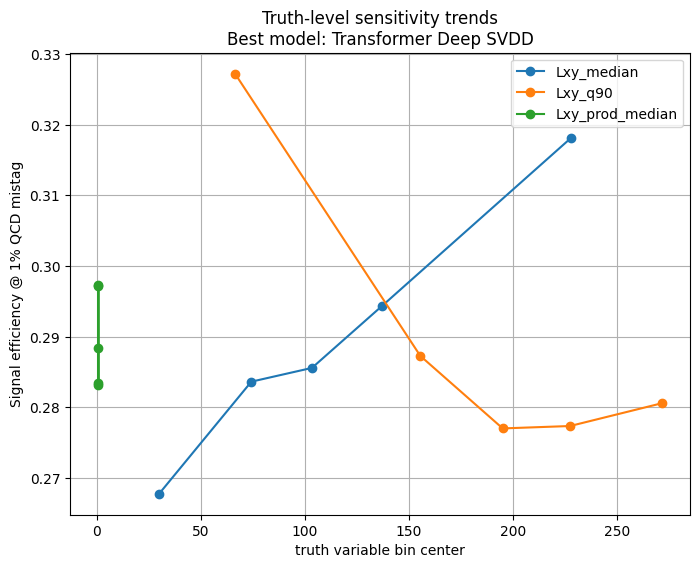

In [18]:
if df_truth is not None and "df_truth_sensitivity" in globals():
    best_model = df_results.iloc[0]["model"]
    df_best_truth = df_truth_sensitivity[df_truth_sensitivity["model"] == best_model].copy()

    display(df_best_truth)

    variables_to_plot = [v for v in ["mass_median", "Lxy_median", "Lxy_q90", "Lxy_prod_median"] if v in df_best_truth["variable"].unique()]

    plt.figure(figsize=(8, 6))

    for var in variables_to_plot:
        d = df_best_truth[df_best_truth["variable"] == var]
        plt.plot(d["bin_center"], d["signal_efficiency"], marker="o", label=var)

    plt.xlabel("truth variable bin center")
    plt.ylabel("Signal efficiency @ 1% QCD mistag")
    plt.title(f"Truth-level sensitivity trends\nBest model: {best_model}")
    plt.legend()
    plt.grid(True)
    plt.show()

## 16. Proxy track-level sensitivity opzionale

,model,proxy,bin_low,bin_high,bin_center,n_signal,eff_at_1pct_mistag
0,Transformer Deep SVDD,track_radiusOfFirstHit_median,-0.514983,-0.490291,-0.502637,14911,0.306619
1,Transformer Deep SVDD,track_radiusOfFirstHit_median,-0.490291,-0.142166,-0.316229,14910,0.271898
2,Transformer Deep SVDD,track_radiusOfFirstHit_median,-0.142166,0.091156,-0.025505,14911,0.268996
3,Transformer Deep SVDD,track_radiusOfFirstHit_median,0.091156,3.684197,1.887676,14911,0.322044


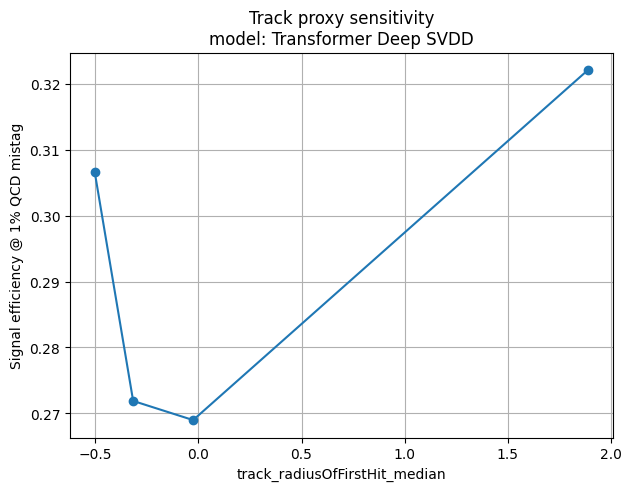

,model,proxy,bin_low,bin_high,bin_center,n_signal,eff_at_1pct_mistag
0,Transformer Deep SVDD,track_abs_d0_median,0.009454,0.014489,0.011971,14911,0.313057
1,Transformer Deep SVDD,track_abs_d0_median,0.014489,0.032898,0.023693,14910,0.235681
2,Transformer Deep SVDD,track_abs_d0_median,0.032898,0.056564,0.044731,14911,0.248944
3,Transformer Deep SVDD,track_abs_d0_median,0.056564,1.328758,0.692661,14911,0.371873


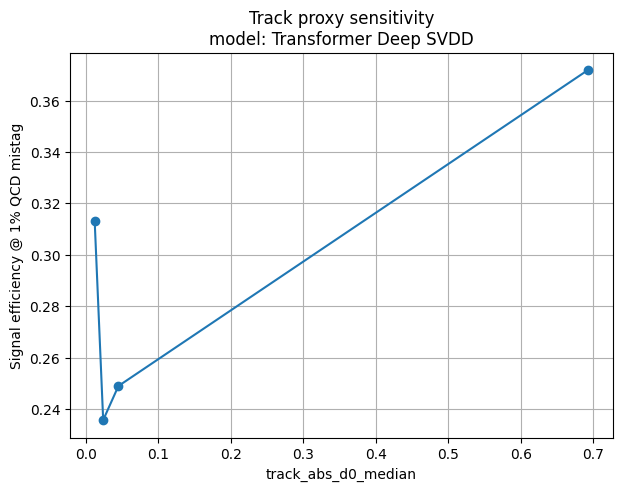

Saved: outputs_task3_v2\track_proxy_sensitivity.csv


In [19]:
# Manteniamo anche le proxy track-level, ma ora sono secondarie rispetto a truth_dark_pions.

proxy_rows = []

if DATASET_FILES is None:
    print("No processed dataset available.")
else:
    data_sig = np.load(DATASET_FILES["test_signal"], allow_pickle=True)

    X_tracks_sig_proxy = data_sig["X_tracks"].astype(np.float32)
    mask_sig_proxy = data_sig["track_mask"].astype(bool)

    if "meta_isDisplaced" in data_sig:
        sig_filter = data_sig["meta_isDisplaced"] == 1
        X_tracks_sig_proxy = X_tracks_sig_proxy[sig_filter]
        mask_sig_proxy = mask_sig_proxy[sig_filter]

    nonempty = mask_sig_proxy.sum(axis=1) > 0
    X_tracks_sig_proxy = X_tracks_sig_proxy[nonempty]
    mask_sig_proxy = mask_sig_proxy[nonempty]

    track_feature_names = list(data_sig["track_feature_names"])

    proxies = []

    if "radiusOfFirstHit" in track_feature_names:
        idx = track_feature_names.index("radiusOfFirstHit")
        vals = X_tracks_sig_proxy[:, :, idx]
        proxy = np.nanmedian(np.where(mask_sig_proxy, vals, np.nan), axis=1)
        proxy = np.nan_to_num(proxy, nan=0.0, posinf=0.0, neginf=0.0)
        proxies.append(("track_radiusOfFirstHit_median", proxy))

    if "d0" in track_feature_names:
        idx = track_feature_names.index("d0")
        vals = np.abs(X_tracks_sig_proxy[:, :, idx])
        proxy = np.nanmedian(np.where(mask_sig_proxy, vals, np.nan), axis=1)
        proxy = np.nan_to_num(proxy, nan=0.0, posinf=0.0, neginf=0.0)
        proxies.append(("track_abs_d0_median", proxy))

    if len(proxies) == 0:
        print("No proxy available.")
    else:
        best_model = df_results.iloc[0]["model"]
        obj = loaded[best_model]

        bg_scores = obj["metrics"]["bg_oriented"]
        sig_scores = obj["metrics"]["sig_oriented"]

        threshold = np.quantile(bg_scores, 0.99)

        for proxy_name, proxy_values in proxies:
            n = min(len(proxy_values), len(sig_scores))

            proxy_values = proxy_values[:n]
            sig_scores_use = sig_scores[:n]

            edges = np.unique(np.quantile(proxy_values, [0, 0.25, 0.50, 0.75, 1.0]))

            rows = []

            for i in range(len(edges) - 1):
                lo = edges[i]
                hi = edges[i + 1]

                if i == len(edges) - 2:
                    mask = (proxy_values >= lo) & (proxy_values <= hi)
                else:
                    mask = (proxy_values >= lo) & (proxy_values < hi)

                if mask.sum() == 0:
                    continue

                eff = np.mean(sig_scores_use[mask] >= threshold)

                rows.append({
                    "model": best_model,
                    "proxy": proxy_name,
                    "bin_low": lo,
                    "bin_high": hi,
                    "bin_center": 0.5 * (lo + hi),
                    "n_signal": int(mask.sum()),
                    "eff_at_1pct_mistag": float(eff),
                })

            df_proxy = pd.DataFrame(rows)
            proxy_rows.append(df_proxy)
            display(df_proxy)

            plt.figure(figsize=(7, 5))
            plt.plot(df_proxy["bin_center"], df_proxy["eff_at_1pct_mistag"], marker="o")
            plt.xlabel(proxy_name)
            plt.ylabel("Signal efficiency @ 1% QCD mistag")
            plt.title(f"Track proxy sensitivity\nmodel: {best_model}")
            plt.grid(True)
            plt.show()

        if len(proxy_rows) > 0:
            df_proxy_all = pd.concat(proxy_rows, ignore_index=True)
            df_proxy_all.to_csv(OUTPUT_DIR / "track_proxy_sensitivity.csv", index=False)
            print("Saved:", OUTPUT_DIR / "track_proxy_sensitivity.csv")

## 17. Salvataggio summary finale

In [20]:
summary = {
    "models_evaluated": df_results["model"].tolist(),
    "best_model_by_auc": df_results.iloc[0]["model"] if len(df_results) else None,
    "best_auc": float(df_results.iloc[0]["best_auc"]) if len(df_results) else None,
    "has_truth_dark_pions": df_truth is not None,
    "output_dir": str(OUTPUT_DIR),
}

with open(OUTPUT_DIR / "task3_v2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

with open(OUTPUT_DIR / "task3_v2_summary.md", "w", encoding="utf-8") as f:
    f.write("# Task 3 v2 Summary\n\n")
    f.write(f"Best model by AUC: **{summary['best_model_by_auc']}**\n\n")
    if summary["best_auc"] is not None:
        f.write(f"Best AUC: **{summary['best_auc']:.4f}**\n\n")
    f.write(f"Truth dark pion information available: **{summary['has_truth_dark_pions']}**\n\n")
    f.write("## Model comparison\n\n")
    f.write(df_results.to_markdown(index=False))

print("Saved:")
print(OUTPUT_DIR / "model_comparison_metrics.csv")
print(OUTPUT_DIR / "task3_v2_summary.json")
print(OUTPUT_DIR / "task3_v2_summary.md")
if df_truth is not None:
    print(OUTPUT_DIR / "truth_dark_pion_per_jet.csv")
    print(OUTPUT_DIR / "truth_dark_pion_sensitivity.csv")

Saved:
outputs_task3_v2\model_comparison_metrics.csv
outputs_task3_v2\task3_v2_summary.json
outputs_task3_v2\task3_v2_summary.md
outputs_task3_v2\truth_dark_pion_per_jet.csv
outputs_task3_v2\truth_dark_pion_sensitivity.csv


## Note per il report

Questa versione copre più fedelmente il Task 3:

- **Score distributions QCD vs EJ**: sezione 6.
- **ROC/AUC**: sezioni 4-5.
- **Efficiency vs mistag**: sezione 5.
- **Sensitivity vs LLP-related quantities**: sezioni 13-15 usando `truth_dark_pions.mass` e `truth_dark_pions.Lxy`.
- **Comparison with supervised approach**: sezioni 8-10.
- **Interpretability / latent-space visualization**: sezioni 11-12.

Nota importante: `truth_dark_pions` è truth-level e va usato solo in evaluation, non come feature del modello.

In [21]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [22]:

def get_model_curve(model_name):
    """
    Recupera FPR, TPR e AUC da uno score unsupervised già caricato in `loaded`.
    """
    obj = loaded[model_name]
    met = obj["metrics"]
    return {
        "name": model_name,
        "fpr": met["fpr"],
        "tpr": met["tpr"],
        "auc": met["best_auc"],
    }


# Scegli qui quali curve unsupervised vuoi mostrare.
# Il codice tiene solo quelle effettivamente disponibili.
wanted_unsup_models = [
    "Aggregate AE",
    "Aggregate VAE reco",
    "Stable RealNVP Flow",
    "Diffusion v2 z-mid",
    "Transformer Set AE total",
    "Transformer Deep SVDD",
]

unsup_curves = []

for name in wanted_unsup_models:
    if name in loaded:
        unsup_curves.append(get_model_curve(name))
    else:
        print(f"[SKIP] {name} not available.")

print("Unsupervised curves selected:")
for c in unsup_curves:
    print(c["name"], c["auc"])

Unsupervised curves selected:
Aggregate AE 0.8409908564147274
Aggregate VAE reco 0.8382788730635101
Stable RealNVP Flow 0.8713137467934208
Diffusion v2 z-mid 0.849824060912429
Transformer Set AE total 0.801245292238821
Transformer Deep SVDD 0.8899255712321649


In [23]:

def aggregate_track_features(X_tracks, mask):
    features = []

    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)

    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)

        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)

        features.extend([mean, std, median, q90, maxv])

    out = np.concatenate(features, axis=1)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

    return out.astype(np.float32)


def build_supervised_inputs(DATASET_FILES, max_per_class=100_000):
    data_bg = np.load(DATASET_FILES["test_background"], allow_pickle=True)
    data_sig = np.load(DATASET_FILES["test_signal"], allow_pickle=True)

    X_jets_bg = data_bg["X_jets"].astype(np.float32)
    X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
    mask_bg = data_bg["track_mask"].astype(bool)

    X_jets_sig = data_sig["X_jets"].astype(np.float32)
    X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
    mask_sig = data_sig["track_mask"].astype(bool)

    # Usa solo signal displaced se disponibile
    if "meta_isDisplaced" in data_sig:
        sig_filter = data_sig["meta_isDisplaced"] == 1
        X_jets_sig = X_jets_sig[sig_filter]
        X_tracks_sig = X_tracks_sig[sig_filter]
        mask_sig = mask_sig[sig_filter]

    # Rimuovi jet senza tracce valide
    bg_filter = mask_bg.sum(axis=1) > 0
    sig_filter = mask_sig.sum(axis=1) > 0

    X_jets_bg = X_jets_bg[bg_filter]
    X_tracks_bg = X_tracks_bg[bg_filter]
    mask_bg = mask_bg[bg_filter]

    X_jets_sig = X_jets_sig[sig_filter]
    X_tracks_sig = X_tracks_sig[sig_filter]
    mask_sig = mask_sig[sig_filter]

    # Limita per velocità e bilanciamento
    rng = np.random.default_rng(42)

    n_bg = min(max_per_class, X_jets_bg.shape[0])
    n_sig = min(max_per_class, X_jets_sig.shape[0])

    idx_bg = rng.choice(X_jets_bg.shape[0], size=n_bg, replace=False)
    idx_sig = rng.choice(X_jets_sig.shape[0], size=n_sig, replace=False)

    X_jets_bg = X_jets_bg[idx_bg]
    X_tracks_bg = X_tracks_bg[idx_bg]
    mask_bg = mask_bg[idx_bg]

    X_jets_sig = X_jets_sig[idx_sig]
    X_tracks_sig = X_tracks_sig[idx_sig]
    mask_sig = mask_sig[idx_sig]

    # Feature aggregate
    A_tracks_bg = aggregate_track_features(X_tracks_bg, mask_bg)
    A_tracks_sig = aggregate_track_features(X_tracks_sig, mask_sig)

    # GBT A: jet + track aggregate
    X_bg_A = np.concatenate([X_jets_bg, A_tracks_bg], axis=1)
    X_sig_A = np.concatenate([X_jets_sig, A_tracks_sig], axis=1)

    # GBT B: solo track aggregate
    X_bg_B = A_tracks_bg
    X_sig_B = A_tracks_sig

    y_bg = np.zeros(X_bg_A.shape[0], dtype=np.int64)
    y_sig = np.ones(X_sig_A.shape[0], dtype=np.int64)

    X_A = np.concatenate([X_bg_A, X_sig_A], axis=0)
    X_B = np.concatenate([X_bg_B, X_sig_B], axis=0)
    y = np.concatenate([y_bg, y_sig], axis=0)

    return X_A, X_B, y


def train_gbt_and_get_curve(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y,
    )

    clf = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1e-3,
        random_state=42,
    )

    clf.fit(X_train, y_train)

    proba = clf.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, proba)
    fpr, tpr, _ = roc_curve(y_test, proba)

    return {
        "name": label,
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc,
        "clf": clf,
    }


X_gbt_A, X_gbt_B, y_gbt = build_supervised_inputs(
    DATASET_FILES=DATASET_FILES,
    max_per_class=100_000,
)

print("GBT A input:", X_gbt_A.shape)
print("GBT B input:", X_gbt_B.shape)
print("Labels:", np.unique(y_gbt, return_counts=True))

gbt_A_curve = train_gbt_and_get_curve(
    X_gbt_A,
    y_gbt,
    label="Supervised GBT A",
)

gbt_B_curve = train_gbt_and_get_curve(
    X_gbt_B,
    y_gbt,
    label="Supervised GBT B",
)

print("GBT A AUC:", gbt_A_curve["auc"])
print("GBT B AUC:", gbt_B_curve["auc"])

GBT A input: (159643, 75)
GBT B input: (159643, 61)
Labels: (array([0, 1]), array([100000,  59643]))
GBT A AUC: 0.9977312412675348
GBT B AUC: 0.9930913783788818


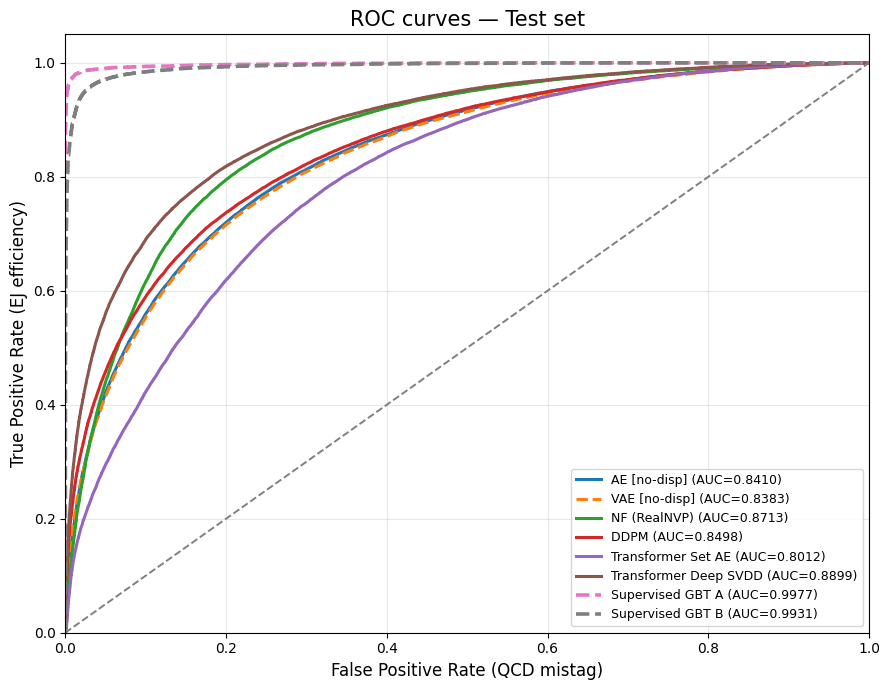

Saved:
outputs_task3_v2\roc_curves_test_set_like_colleagues.png
outputs_task3_v2\roc_curves_test_set_like_colleagues.pdf


In [24]:

plt.figure(figsize=(9, 7))

# Stile curve unsupervised
unsup_styles = {
    "Aggregate AE": {
        "label": "AE [no-disp]",
        "linestyle": "-",
        "linewidth": 2.2,
    },
    "Aggregate VAE reco": {
        "label": "VAE [no-disp]",
        "linestyle": "--",
        "linewidth": 2.2,
    },
    "Stable RealNVP Flow": {
        "label": "NF (RealNVP)",
        "linestyle": "-",
        "linewidth": 2.2,
    },
    "Diffusion v2 z-mid": {
        "label": "DDPM",
        "linestyle": "-",
        "linewidth": 2.2,
    },
    "Transformer Set AE total": {
        "label": "Transformer Set AE",
        "linestyle": "-",
        "linewidth": 2.2,
    },
    "Transformer Deep SVDD": {
        "label": "Transformer Deep SVDD",
        "linestyle": "-",
        "linewidth": 2.2,
    },
}

for curve in unsup_curves:
    name = curve["name"]
    style = unsup_styles.get(
        name,
        {
            "label": name,
            "linestyle": "-",
            "linewidth": 2.2,
        },
    )

    plt.plot(
        curve["fpr"],
        curve["tpr"],
        linestyle=style["linestyle"],
        linewidth=style["linewidth"],
        label=f"{style['label']} (AUC={curve['auc']:.4f})",
    )

# Supervised curves
plt.plot(
    gbt_A_curve["fpr"],
    gbt_A_curve["tpr"],
    linestyle="--",
    linewidth=2.6,
    label=f"Supervised GBT A (AUC={gbt_A_curve['auc']:.4f})",
)

plt.plot(
    gbt_B_curve["fpr"],
    gbt_B_curve["tpr"],
    linestyle="--",
    linewidth=2.6,
    label=f"Supervised GBT B (AUC={gbt_B_curve['auc']:.4f})",
)

# Random baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.4,
    color="gray",
    label=None,
)

plt.xlabel("False Positive Rate (QCD mistag)", fontsize=12)
plt.ylabel("True Positive Rate (EJ efficiency)", fontsize=12)
plt.title("ROC curves — Test set", fontsize=15)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=9, loc="lower right")

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)

plt.tight_layout()

out_png = OUTPUT_DIR / "roc_curves_test_set_like_colleagues.png"
out_pdf = OUTPUT_DIR / "roc_curves_test_set_like_colleagues.pdf"

plt.savefig(out_png, dpi=300)
plt.savefig(out_pdf)

plt.show()

print("Saved:")
print(out_png)
print(out_pdf)

In [25]:
# ============================================================
# FINAL TABLE
# ============================================================

final_rows = []

for curve in unsup_curves:
    final_rows.append({
        "model": unsup_styles.get(curve["name"], {}).get("label", curve["name"]),
        "type": "unsupervised",
        "auc": curve["auc"],
    })

final_rows.append({
    "model": "Supervised GBT A",
    "type": "supervised",
    "auc": gbt_A_curve["auc"],
})

final_rows.append({
    "model": "Supervised GBT B",
    "type": "supervised",
    "auc": gbt_B_curve["auc"],
})

df_final_roc = pd.DataFrame(final_rows).sort_values("auc", ascending=False)
display(df_final_roc)

df_final_roc.to_csv(
    OUTPUT_DIR / "final_roc_curves_table_like_colleagues.csv",
    index=False,
)

print("Saved:", OUTPUT_DIR / "final_roc_curves_table_like_colleagues.csv")

,model,type,auc
6,Supervised GBT A,supervised,0.997731
7,Supervised GBT B,supervised,0.993091
5,Transformer Deep SVDD,unsupervised,0.889926
2,NF (RealNVP),unsupervised,0.871314
3,DDPM,unsupervised,0.849824
0,AE [no-disp],unsupervised,0.840991
1,VAE [no-disp],unsupervised,0.838279
4,Transformer Set AE,unsupervised,0.801245


Saved: outputs_task3_v2\final_roc_curves_table_like_colleagues.csv
